# Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import path
import re
import pickle
import joblib
import shap
from pathlib import Path
import os

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from feature_engine.selection import MRMR

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier

from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, f1_score, balanced_accuracy_score, classification_report, fbeta_score, make_scorer, ConfusionMatrixDisplay
from sklearn.inspection import PartialDependenceDisplay
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from mrmr import mrmr_classif

import warnings

warnings.simplefilter(action = 'ignore', category = FutureWarning)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [3]:
# Go up one level from analysis/
base_path = Path.cwd().parent
data_path = base_path / "data" / "hotel_bookings.csv"
hotels = pd.read_csv(data_path)

display(hotels.head())
hotels['is_canceled'].value_counts()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [4]:
hotels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

## Split data into train data and new/unseen data

In [5]:
train_data, new_data = train_test_split(hotels,test_size=0.10,random_state=42,stratify=hotels['is_canceled'])

data_path = os.path.join("..", "data", "new_data.csv")
new_data.to_csv(data_path, index=False)
print(f"Data saved to: {data_path}")

Data saved to: ..\data\new_data.csv


In [6]:
train_data

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
4745,Resort Hotel,0,169,2016,March,14,31,0,3,2,0.0,0,BB,PRT,Groups,Direct,0,0,0,A,B,1,Refundable,NaN,223.0,0,Transient-Party,72.00,1,0,Check-Out,2016-04-03
81970,City Hotel,1,115,2016,March,13,20,2,0,1,0.0,0,BB,PRT,Groups,TA/TO,0,1,0,A,A,0,Non Refund,41.0,NaN,22,Transient,70.00,0,0,Canceled,2015-12-18
117025,City Hotel,0,465,2017,July,30,26,0,3,2,0.0,0,BB,GBR,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,229.0,NaN,0,Transient-Party,112.67,0,1,Check-Out,2017-07-29
49339,City Hotel,1,9,2016,April,16,11,1,0,1,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,95.00,0,0,Canceled,2016-04-02
87847,City Hotel,0,77,2016,April,18,25,1,1,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,D,0,No Deposit,9.0,NaN,0,Transient,96.30,0,1,Check-Out,2016-04-27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62948,City Hotel,1,61,2017,January,4,25,0,2,2,0.0,0,BB,PRT,Groups,TA/TO,0,0,0,A,A,0,Non Refund,326.0,NaN,0,Transient,80.00,0,0,Canceled,2016-11-25
36939,Resort Hotel,0,135,2017,May,22,30,0,3,2,0.0,0,BB,CN,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,241.0,NaN,0,Transient,94.97,0,2,Check-Out,2017-06-02
58470,City Hotel,1,97,2016,October,42,12,1,4,2,0.0,0,BB,USA,Direct,Direct,0,0,0,F,F,3,No Deposit,14.0,NaN,0,Transient,176.80,0,0,No-Show,2016-10-12
56169,City Hotel,1,179,2016,August,36,31,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,B,B,1,No Deposit,9.0,NaN,0,Transient-Party,103.69,0,0,Canceled,2016-06-29


# Data Cleaning

In [7]:
train_data = train_data.drop(['company','arrival_date_year','arrival_date_month','arrival_date_week_number','arrival_date_day_of_month', 'reservation_status_date','reservation_status'], axis=1)

In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107451 entries, 4745 to 6068
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           107451 non-null  object 
 1   is_canceled                     107451 non-null  int64  
 2   lead_time                       107451 non-null  int64  
 3   stays_in_weekend_nights         107451 non-null  int64  
 4   stays_in_week_nights            107451 non-null  int64  
 5   adults                          107451 non-null  int64  
 6   children                        107447 non-null  float64
 7   babies                          107451 non-null  int64  
 8   meal                            107451 non-null  object 
 9   country                         107004 non-null  object 
 10  market_segment                  107451 non-null  object 
 11  distribution_channel            107451 non-null  object 
 12  is_repeated_guest   

In [9]:
def smart_encode_hotels(hotels):
    hotels_encoded = hotels.copy()
    
    cat_cols = hotels_encoded.select_dtypes(include=['object']).columns
    
    for col in cat_cols:
        if col == 'is_canceled':
            continue    
            
        n_unique = hotels_encoded[col].nunique()
        
        if n_unique <= 2:
            hotels_encoded[col] = pd.factorize(hotels_encoded[col])[0] 
            
        elif 2 < n_unique <= 6:
            hotels_encoded = pd.get_dummies(hotels_encoded, columns=[col], drop_first=True)
            
        else:
            top_5 = hotels_encoded[col].value_counts().nlargest(6).index
            hotels_encoded[col] = hotels_encoded[col].where(hotels_encoded[col].isin(top_5))
            hotels_encoded = pd.get_dummies(hotels_encoded, columns=[col], drop_first=True)
            
    return hotels_encoded

train_data = smart_encode_hotels(train_data)

In [10]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107451 entries, 4745 to 6068
Data columns (total 50 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           107451 non-null  int64  
 1   is_canceled                     107451 non-null  int64  
 2   lead_time                       107451 non-null  int64  
 3   stays_in_weekend_nights         107451 non-null  int64  
 4   stays_in_week_nights            107451 non-null  int64  
 5   adults                          107451 non-null  int64  
 6   children                        107447 non-null  float64
 7   babies                          107451 non-null  int64  
 8   is_repeated_guest               107451 non-null  int64  
 9   previous_cancellations          107451 non-null  int64  
 10  previous_bookings_not_canceled  107451 non-null  int64  
 11  booking_changes                 107451 non-null  int64  
 12  agent               

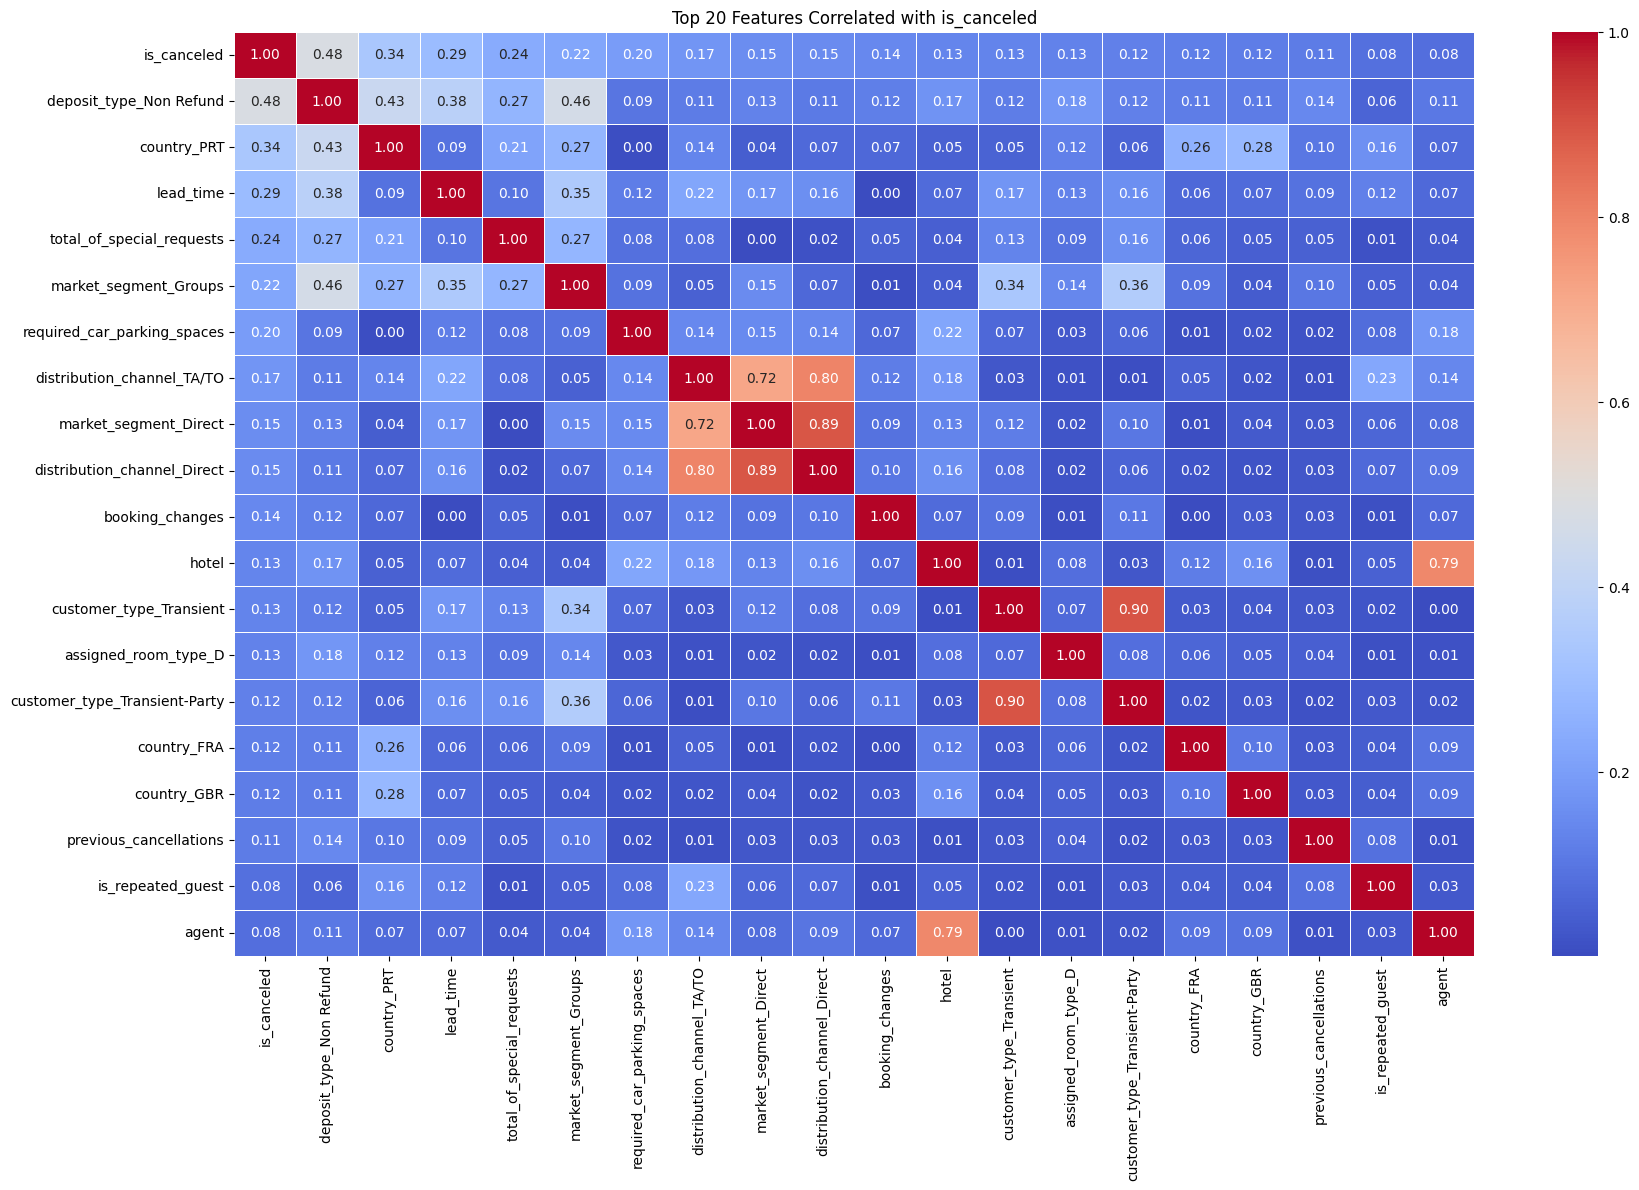

In [11]:
correlations = train_data.corr()['is_canceled'].abs().sort_values(ascending=False)

top_20_cols = correlations.head(20).index

top_20_corr = train_data[top_20_cols].corr().abs()

plt.figure(figsize=(20, 12))
sns.heatmap(top_20_corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Top 20 Features Correlated with is_canceled')
plt.show()

In [12]:
data_path = os.path.join("..", "data", "train_data.csv")
train_data.to_csv(data_path, index=False)
print(f"Data saved to: {data_path}")

Data saved to: ..\data\train_data.csv


In [13]:
X = smart_encode_hotels(train_data)

In [14]:
X = X.drop(columns=['is_canceled'], errors='ignore')
y = train_data['is_canceled']

In [15]:
dummy_columns = X.columns.tolist()

### Save the dummy columns in a pickle file

In [16]:
pickle_folder = os.path.join("..", "pickle files")
if not os.path.exists(pickle_folder):
    os.makedirs(pickle_folder)

pickle_path = os.path.join(pickle_folder, 'dummy_cols.pickle')
with open(pickle_path, 'wb') as f:
    pickle.dump(dummy_columns, f)

print(f"Pickle file created successfully in: {pickle_path}")

Pickle file created successfully in: ..\pickle files\dummy_cols.pickle


In [17]:
display(hotels.info())
display(train_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

None

<class 'pandas.core.frame.DataFrame'>
Index: 107451 entries, 4745 to 6068
Data columns (total 50 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           107451 non-null  int64  
 1   is_canceled                     107451 non-null  int64  
 2   lead_time                       107451 non-null  int64  
 3   stays_in_weekend_nights         107451 non-null  int64  
 4   stays_in_week_nights            107451 non-null  int64  
 5   adults                          107451 non-null  int64  
 6   children                        107447 non-null  float64
 7   babies                          107451 non-null  int64  
 8   is_repeated_guest               107451 non-null  int64  
 9   previous_cancellations          107451 non-null  int64  
 10  previous_bookings_not_canceled  107451 non-null  int64  
 11  booking_changes                 107451 non-null  int64  
 12  agent               

None

# Analysis

## Feature Importance

In [18]:
df_clean = train_data.copy()

In [19]:
df_clean[df_clean.select_dtypes(include='bool').columns] = \
    df_clean.select_dtypes(include='bool').astype(int)

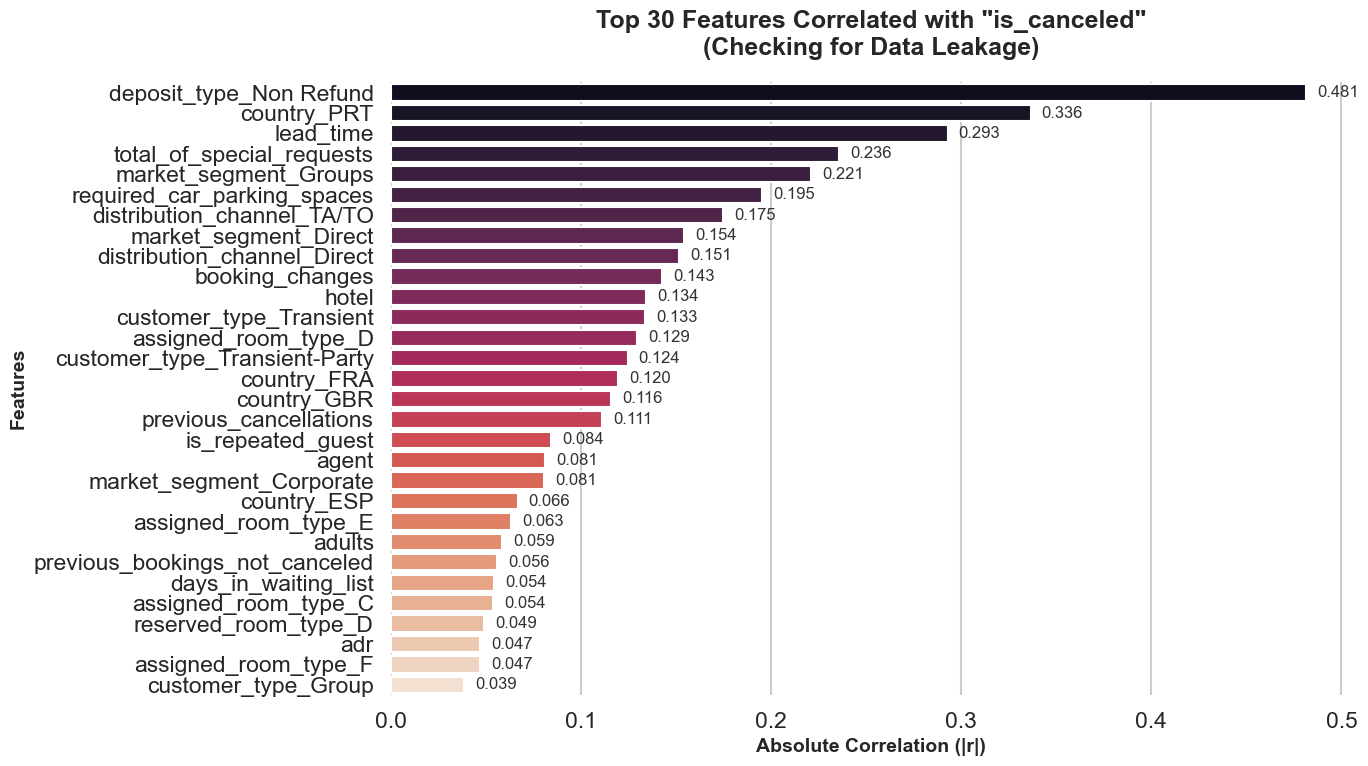

In [ ]:
target = 'target'

corrs = (
    df_clean
    .drop(columns=['is_canceled'])
    .select_dtypes(include=[np.number])
    .corrwith(df_clean['is_canceled'])
    .abs()
    .sort_values(ascending=False)
)

corrs.head(30)
corrs = (
    df_clean
    .drop(columns=['is_canceled'])
    .select_dtypes(include=[np.number,'bool'])
    .corrwith(df_clean['is_canceled'])
    .abs()
    .sort_values(ascending=False)
)

top_corrs = corrs.head(30)

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(14, 8))


ax = sns.barplot(
    x=top_corrs.values, 
    y=top_corrs.index, 
    palette="rocket",   
    hue=top_corrs.index, 
    legend=False
)


plt.title('Top 30 Features Correlated with "is_canceled"\n(Checking for Data Leakage)', 
          fontsize=18, weight='bold', pad=20)
plt.xlabel('Absolute Correlation (|r|)', fontsize=14, weight='bold')
plt.ylabel('Features', fontsize=14, weight='bold')

for p in ax.patches:
    width = p.get_width()
    # Add a slight offset (xytext) so the text doesn't touch the bar
    ax.annotate(f'{width:.3f}', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(8, 0), 
                textcoords='offset points',
                fontsize=12,
                color='#333333')

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [21]:
df_clean.describe()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,meal_FB,meal_HB,meal_SC,meal_Undefined,country_ESP,country_FRA,country_GBR,country_ITA,country_PRT,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_B,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
count,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107447.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.00000,92737.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000,107451.000000
mean,0.665280,0.370420,103.962755,0.927725,2.498367,1.856297,0.103605,0.007911,0.031577,0.085360,0.135708,0.22118,86.716090,2.332589,101.841488,0.062410,0.571339,0.006701,0.120567,0.089399,0.009791,0.071558,0.087240,0.101628,0.031531,0.406930,0.044299,0.105174,0.165992,0.202846,0.473406,0.122270,0.001629,0.820365,0.000037,0.009344,0.160371,0.054276,0.024467,0.017487,0.019888,0.212255,0.064885,0.031521,0.021321,0.122074,0.001396,0.004849,0.750249,0.210989
std,0.471895,0.482919,106.922477,0.997151,1.905336,0.578987,0.398103,0.098063,0.174872,0.825811,1.498866,0.65455,110.739293,17.682013,50.761577,0.245376,0.793212,0.081584,0.325624,0.285320,0.098462,0.257756,0.282187,0.302160,0.174748,0.491264,0.205760,0.306778,0.372075,0.402121,0.499295,0.327599,0.040324,0.383885,0.006101,0.096211,0.366951,0.226562,0.154495,0.131078,0.139617,0.408906,0.246325,0.174723,0.144454,0.327373,0.037337,0.069464,0.432871,0.408013
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,-6.380000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,9.000000,0.000000,69.330000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1.000000,0.000000,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,14.000000,0.000000,94.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,1.000000,160.000000,2.000000,3.000000,2.000000,0.000000,0.000000,

In [22]:
df_clean.shape

(107451, 50)

### Spliting our Dataset

In [23]:
X = df_clean.drop(columns ='is_canceled')
y = df_clean.is_canceled

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

## Running a simple model

In [25]:
rf = RandomForestClassifier(random_state=24)

In [26]:
imputer = KNNImputer(n_neighbors=3)

# FIT on train
X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# TRANSFORM on test (NO fit)
X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

In [ ]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

              precision    recall  f1-score   support

           0       0.89      0.92      0.91     13530
           1       0.86      0.81      0.84      7961

    accuracy                           0.88     21491
   macro avg       0.88      0.87      0.87     21491
weighted avg       0.88      0.88      0.88     21491



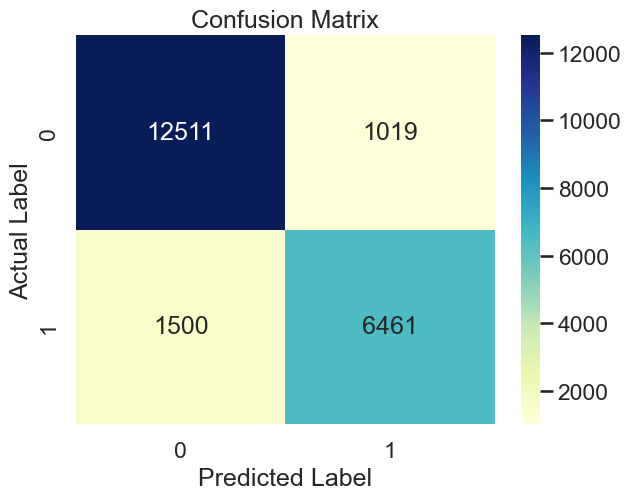

In [28]:
model = rf.fit(X_train, y_train)

y_pred = model.predict(X_test)

cnf_matrix = confusion_matrix(y_test, y_pred)

class_names = [0,1]
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

#heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot = True, cmap = "YlGnBu", fmt = "g")
plt.tight_layout()
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
None

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.90     13530
           1       0.85      0.81      0.83      7961

    accuracy                           0.88     21491
   macro avg       0.87      0.86      0.87     21491
weighted avg       0.88      0.88      0.88     21491



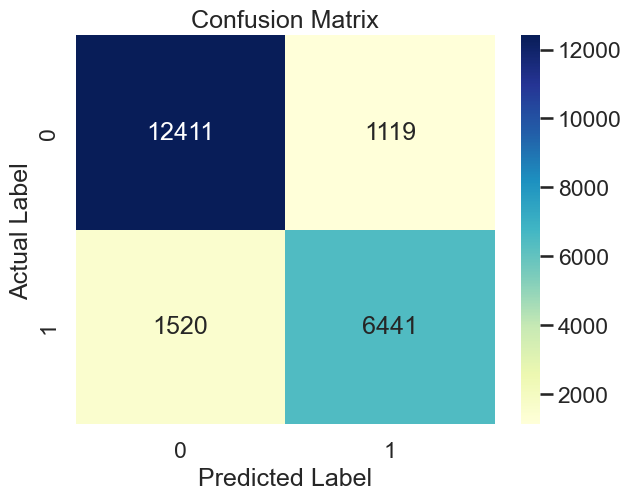

In [29]:
feat_imps = pd.Series(rf.feature_importances_, index=X.columns, name="feature_importance")
feat_imps = feat_imps.sort_values(ascending=False)

important_features_20 = feat_imps.head(20).index.tolist()

X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)

X_train_20 = X_train_df[important_features_20]
X_test_20  = X_test_df[important_features_20]

X_train_20

# Run RandomForest with top 20 features
model1 = rf.fit(X_train_20, y_train)

y_pred_20 = model1.predict(X_test_20)

cnf_matrix = confusion_matrix(y_test, y_pred_20)

class_names = [0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

#heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot = True, cmap = "YlGnBu", fmt = "g")
plt.tight_layout()
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
None

print(classification_report(y_test, y_pred_20))

## Partial Dependence

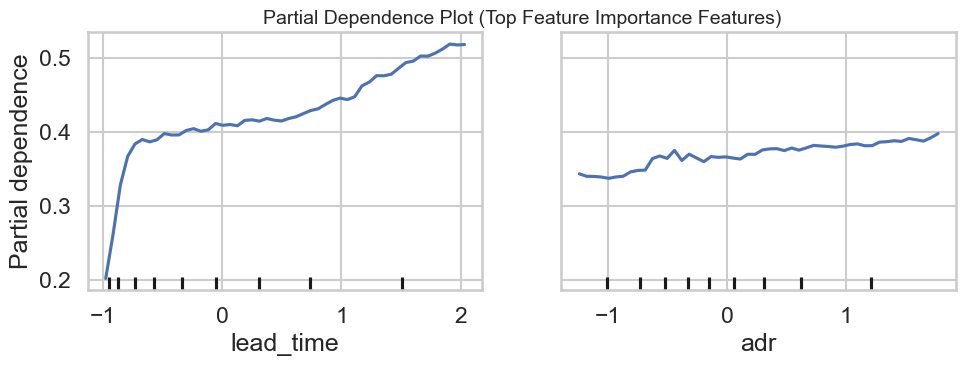

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))

PartialDependenceDisplay.from_estimator(
    model1,
    X_test_20,
    features=[0, 1],
    feature_names=X_test_20.columns,
    response_method="predict_proba",
    grid_resolution=50,
    ax=ax
)

ax.set_title("Partial Dependence Plot (Top Feature Importance Features)", fontsize=14)
plt.tight_layout()
plt.show()

### Top 20 Features Retained by MRMR

In [31]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)

y_train_s = pd.Series(np.asarray(y_train).ravel(), name="target")

X_train_df = X_train_df.reset_index(drop=True)
y_train_s  = y_train_s.reset_index(drop=True)

mrmr_features = mrmr_classif(X=X_train_df, y=y_train_s, K=20, n_jobs=1)
print(mrmr_features)

100%|██████████| 20/20 [00:01<00:00, 18.33it/s]

['deposit_type_Non Refund', 'meal_Undefined', 'required_car_parking_spaces', 'country_PRT', 'lead_time', 'total_of_special_requests', 'booking_changes', 'market_segment_Direct', 'market_segment_Groups', 'country_FRA', 'assigned_room_type_D', 'previous_cancellations', 'distribution_channel_TA/TO', 'country_GBR', 'customer_type_Transient', 'hotel', 'distribution_channel_Direct', 'customer_type_Transient-Party', 'is_repeated_guest', 'agent']


In [32]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df  = pd.DataFrame(X_test,  columns=X.columns)

X_train_mrmr = X_train_df[mrmr_features]
X_test_mrmr  = X_test_df[mrmr_features]

In [33]:
rf_mrmr = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_mrmr.fit(X_train_mrmr, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [34]:
X_test_mrmr.shape

(21491, 20)

In [35]:
X_train_mrmr.shape

(85960, 20)

In [36]:
y_test.shape

(21491,)

In [37]:
y_train.shape

(85960,)

              precision    recall  f1-score   support

           0       0.88      0.89      0.89     13530
           1       0.82      0.79      0.80      7961

    accuracy                           0.86     21491
   macro avg       0.85      0.84      0.85     21491
weighted avg       0.86      0.86      0.86     21491



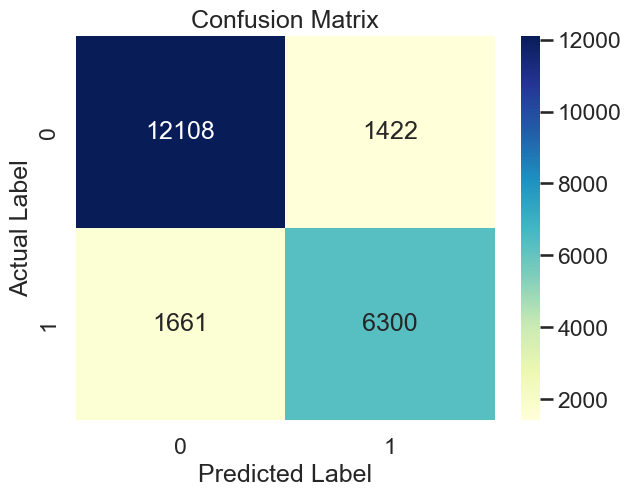

In [38]:
y_pred_mrmr = rf_mrmr.predict(X_test_mrmr)

cnf_matrix = confusion_matrix(y_test, y_pred_mrmr)

class_names = [0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

#heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot = True, cmap = "YlGnBu", fmt = "g")
plt.tight_layout()
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
None

print(classification_report(y_test, y_pred_mrmr))

### Save the Parts used in the Analysis

In [39]:
pickle_folder = os.path.join("..", "pickle files")
if not os.path.exists(pickle_folder):
    os.makedirs(pickle_folder)

# Imputer
imputer_path = os.path.join(pickle_folder, 'analysis_imputer.pickle')
with open(imputer_path, 'wb') as f:
    pickle.dump(imputer, f)
print(f"Imputer saved: {imputer_path}")

# Scaler
scaler_path = os.path.join(pickle_folder, 'analysis_scaler.pickle')
with open(scaler_path, 'wb') as f:
    pickle.dump(sc, f)
print(f"Scaler saved: {scaler_path}")

# Original Model
model_path = os.path.join(pickle_folder, 'analysis_rfc_model.pickle')
with open(model_path, 'wb') as f:
    pickle.dump(model, f)
print(f"Original model saved: {model_path}")

# MRMR Features
mrmr_features_path = os.path.join(pickle_folder, 'analysis_mrmr.pickle')
with open(mrmr_features_path, 'wb') as f:
    pickle.dump(mrmr_features, f)
print(f"MRMR features saved: {mrmr_features_path}")

# Model trained on MRMR features
rf_mrmr_path = os.path.join(pickle_folder, 'analysis_rfc_mrmr.pickle')
with open(rf_mrmr_path, 'wb') as f:
    pickle.dump(rf_mrmr, f)
print(f"MRMR model saved: {rf_mrmr_path}")

# FIS 20 Features
fis_20_path = os.path.join(pickle_folder, 'analysis_fis_20.pickle')
with open(fis_20_path, 'wb') as f:
    pickle.dump(important_features_20, f)
print(f"FIS 20 features saved: {fis_20_path}")

# Model trained on FIS 20 features
fis_20_model_path = os.path.join(pickle_folder, 'analysis_fis_20_model.pickle')
with open(fis_20_model_path, 'wb') as f:
    pickle.dump(model1, f)
print(f"FIS 20 model saved: {fis_20_model_path}")

Imputer saved: ..\pickle files\analysis_imputer.pickle
Scaler saved: ..\pickle files\analysis_scaler.pickle
Original model saved: ..\pickle files\analysis_rfc_model.pickle
MRMR features saved: ..\pickle files\analysis_mrmr.pickle
MRMR model saved: ..\pickle files\analysis_rfc_mrmr.pickle
FIS 20 features saved: ..\pickle files\analysis_fis_20.pickle
FIS 20 model saved: ..\pickle files\analysis_fis_20_model.pickle


# Modeling

## Run 8 Baseline Models and Compare

In [40]:
base_path = Path.cwd()
data_dir = base_path / "data"
data_dir.mkdir(exist_ok=True)

In [41]:
data_path = os.path.join("..", "data", "train_data.csv")
df = pd.read_csv(data_path)

display(df)
df['is_canceled'].value_counts()

,hotel,is_canceled,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,meal_FB,meal_HB,meal_SC,meal_Undefined,country_ESP,country_FRA,country_GBR,country_ITA,country_PRT,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,reserved_room_type_B,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,assigned_room_type_C,assigned_room_type_D,assigned_room_type_E,assigned_room_type_F,assigned_room_type_G,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party
0,0,0,169,0,3,2,0.0,0,0,0,0,1,NaN,0,72.00,1,0,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True
1,1,1,115,2,0,1,0.0,0,0,1,0,0,41.0,22,70.00,0,0,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
2,1,0,465,0,3,2,0.0,0,0,0,0,0,229.0,0,112.67,0,1,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,1,9,1,0,1,0.0,0,0,0,0,0,9.0,0,95.00,0,0,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
4,1,0,77,1,1,2,0.0,0,0,0,0,0,9.0,0,96.30,0,1,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107446,1,1,61,0,2,2,0.0,0,0,0,0,0,326.0,0,80.00,0,0,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False
107447,0,0,135,0,3,2,0.0,0,0,0,0,0,241.0,0,94.97,0,2,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False
107448,1,1,97,1,4,2,0.0,0,0,0,0,3,14.0,0,176.80,0,0,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
107449,1,1,179,0,2,2,0.0,0,0,0,0,1,9.0,0,103.69,0,0,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True


is_canceled
0    67649
1    39802
Name: count, dtype: int64

In [42]:
X.isna().sum()

hotel                                 0
lead_time                             0
stays_in_weekend_nights               0
stays_in_week_nights                  0
adults                                0
children                              4
babies                                0
is_repeated_guest                     0
previous_cancellations                0
previous_bookings_not_canceled        0
booking_changes                       0
agent                             14714
days_in_waiting_list                  0
adr                                   0
required_car_parking_spaces           0
total_of_special_requests             0
meal_FB                               0
meal_HB                               0
meal_SC                               0
meal_Undefined                        0
country_ESP                           0
country_FRA                           0
country_GBR                           0
country_ITA                           0
country_PRT                           0


Model: LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     13530
           1       0.72      0.77      0.74      7961

    accuracy                           0.80     21491
   macro avg       0.79      0.80      0.79     21491
weighted avg       0.81      0.80      0.80     21491

Model: RandomForestClassifier(random_state=42)
              precision    recall  f1-score   support

           0       0.90      0.91      0.91     13530
           1       0.84      0.84      0.84      7961

    accuracy                           0.88     21491
   macro avg       0.87      0.87      0.87     21491
weighted avg       0.88      0.88      0.88     21491

Model: AdaBoostClassifier(random_state=42)
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     13530
           1       0.72      0.78      0.75      7961

    accur

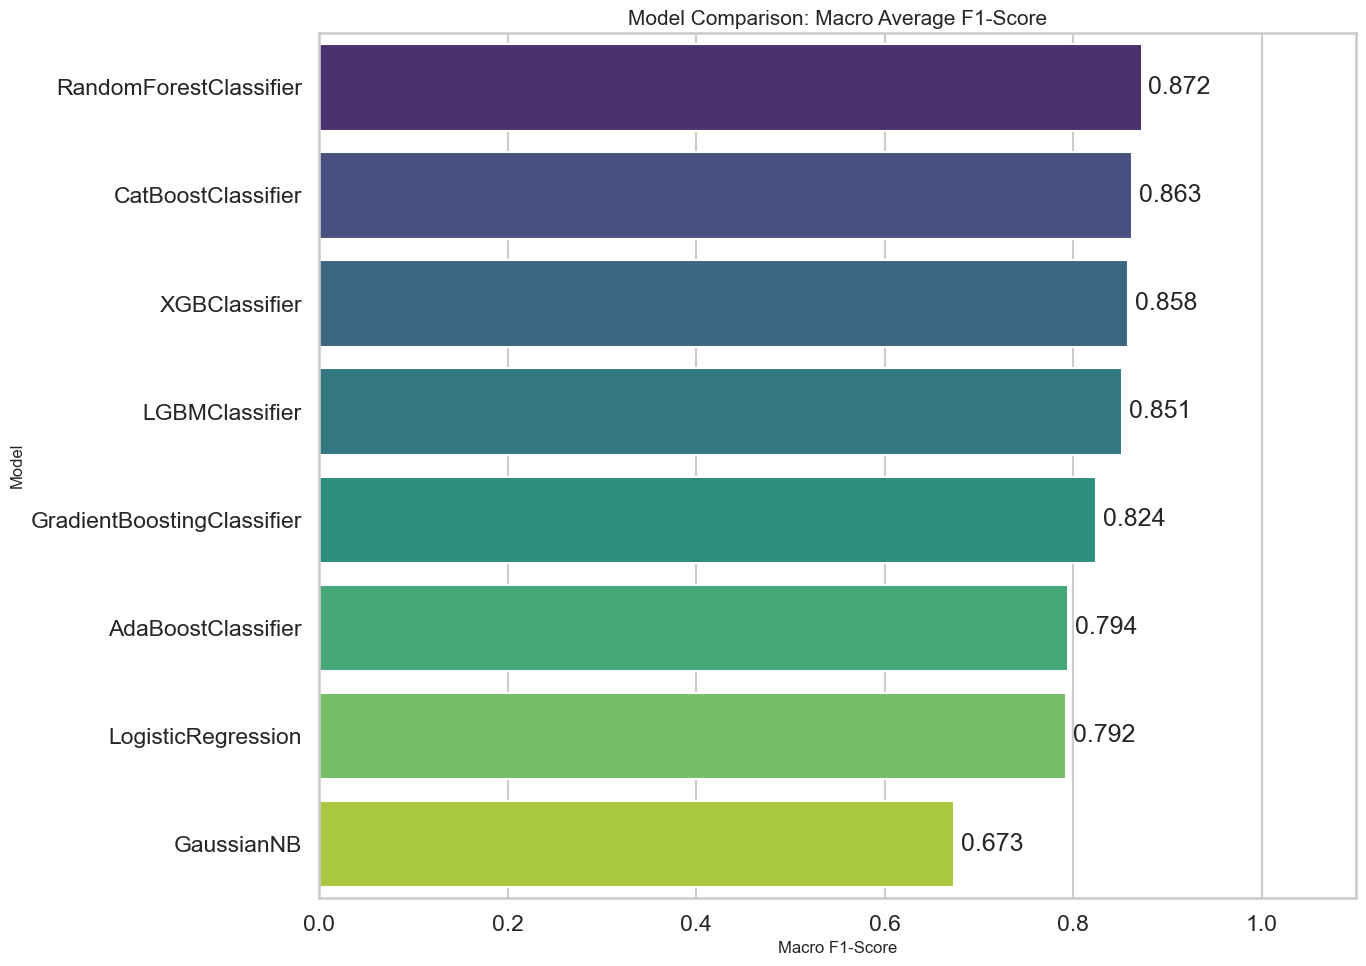

In [43]:
X = df.drop(columns=['is_canceled'])
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = [
    LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"),
    RandomForestClassifier(random_state=42),
    AdaBoostClassifier(random_state=42),
    GaussianNB(),
    CatBoostClassifier(random_state=42, verbose=0),
    GradientBoostingClassifier(random_state=42),
    # SVC(random_state=0, class_weight="balanced", probability=True), # SVC can be very slow, especially with large datasets, so it's commented out for now
    LGBMClassifier(random_state=42, verbose=-1),
    XGBClassifier(random_state=42)
]

for model in models:
    pipe = ImbPipeline(
            steps=[
                ('imputer', SimpleImputer()),
                ('scaler', StandardScaler()),
                ('smote' , SMOTE(random_state=42)),
                ('selectk', SelectKBest(score_func=f_classif, k='all')),
                ('model', model)
            ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(f'Model: {model}')
    print(classification_report(y_test, y_pred))
    
results_list = []

for model in models:
    model_name = model.__class__.__name__ # Extract model name for the plot
    
    pipe = ImbPipeline(
            steps=[
                ('imputer', SimpleImputer()),
                ('scaler', StandardScaler()),
                ('smote' , SMOTE(random_state=42)),
                ('selectk', SelectKBest(score_func=f_classif, k='all')),
                ('model', model)
            ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results_list.append({
        'Model': model_name,
        'Macro_F1': report['macro avg']['f1-score']
    })

plot_df = pd.DataFrame(results_list).sort_values(by='Macro_F1', ascending=False)

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

ax = sns.barplot(data=plot_df, x='Macro_F1', y='Model', palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_width(), '.3f'), 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha = 'left', va = 'center', 
                xytext = (5, 0), 
                textcoords = 'offset points')

plt.title('Model Comparison: Macro Average F1-Score', fontsize=15)
plt.xlabel('Macro F1-Score', fontsize=12)
plt.ylabel('Model', fontsize=12)
plt.xlim(0, 1.1)  # Scale to 1.1 to leave room for labels
plt.tight_layout()
plt.show()

## Hypertune the 3 best models on the 30 selectKbest columns (F1 Priority)

In [ ]:
f2_scorer = make_scorer(fbeta_score, beta=2, average='macro') # this isnt used in the current codeblock but will be used in the next section for tuning the f2 score

from sklearn.metrics import fbeta_score, classification_report

def get_model_metrics(y_true, y_pred, method_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    f2 = fbeta_score(y_true, y_pred, beta=2, average='macro')
    
    return {
        "method": method_name,
        "accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"],
        "f2_macro": f2,
        "recall_macro": report["macro avg"]["recall"],
        "precision_macro": report["macro avg"]["precision"]
    }

all_metrics = []

xgb_params = {
    'model__n_estimators': [100, 200, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 6, 9],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

cat_params = {
    'model__iterations': [100, 200, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [4, 6, 8],
    'model__l2_leaf_reg': [1, 3, 5, 9]
}

search_results = {}

tuned_models = {
    "XGBoost_SelectKbest_F1_Tuned": (XGBClassifier(random_state=42), xgb_params),
    "CatBoost_SelectKbest_F1_Tuned": (CatBoostClassifier(random_state=42, logging_level='Silent'), cat_params)
}

for name, (model_obj, params) in tuned_models.items():
    pipe = ImbPipeline(steps=[
        ('imputer', SimpleImputer()),
        ('scaler', StandardScaler()),
        ('selectk', SelectKBest(score_func=f_classif, k=30)),
        ('smote' , SMOTE(random_state=42)),
        ('model', model_obj)
    ])
    
    f1_rs = RandomizedSearchCV(pipe, param_distributions=params, n_iter=10, 
                            cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
    
    print(f"Tuning {name}...")
    f1_rs.fit(X_train, y_train)
    print(f"Best {name} Params:\n{f1_rs.best_params_}\n")     
    # Save results to search_results dict
    search_results[name] = f1_rs
    
    # Extract metrics for plotting
    y_pred = f1_rs.predict(X_test)
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}\n")
    print(f"Confusion Matrix for {name}:\n{confusion_matrix(y_test, y_pred)}\n")
    all_metrics.append(get_model_metrics(y_test, y_pred, name))

rf_pipe = ImbPipeline(steps=[
    ('imputer', SimpleImputer()), # Placeholder
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=30)),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))])

rf_params = {
    # This swaps the entire imputer object during the search
    'imputer': [
        SimpleImputer(strategy='median'), 
        KNNImputer(n_neighbors=5)
    ],
    'model__n_estimators': [100, 300],
    'model__max_depth': [None, 10, 20],   # None allows trees to grow until pure
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2, 4], # Minimum samples required at a leaf node
    'model__max_features': ['sqrt', 'log2'] # How many features to consider at each split
}

f1_rs_rf = RandomizedSearchCV(
    rf_pipe, 
    param_distributions=rf_params,
    n_iter=20, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1, 
    verbose=1, 
    random_state=42
)

print("Tuning RandomForest with Imputer & Feature Selection testing...")
f1_rs_rf.fit(X_train, y_train)

print(f"Best RandomForest Params:\n{f1_rs_rf.best_params_}\n")
y_pred_rf = f1_rs_rf.predict(X_test)
print(f"Classification Report for RandomForest_SelectKbest_F1_Tuned:\n{classification_report(y_test, y_pred_rf)}\n")
print(f"Confusion Matrix for RandomForest_SelectKbest_F1_Tuned:\n{confusion_matrix(y_test, y_pred_rf)}\n")
all_metrics.append(get_model_metrics(y_test, y_pred_rf, "RandomForest_SelectKbest_F1_Tuned"))

f1_results_df = pd.DataFrame(all_metrics)

display(f1_results_df.sort_values('f1_macro', ascending=False))

Tuning XGBoost_SelectKbest_F1_Tuned...
Best XGBoost_SelectKbest_F1_Tuned Params:
{'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 9, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}

Classification Report for XGBoost_SelectKbest_F1_Tuned:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88     13530
           1       0.78      0.86      0.82      7961

    accuracy                           0.86     21491
   macro avg       0.85      0.86      0.85     21491
weighted avg       0.86      0.86      0.86     21491


Confusion Matrix for XGBoost_SelectKbest_F1_Tuned:
[[11615  1915]
 [ 1151  6810]]

Tuning CatBoost_SelectKbest_F1_Tuned...
Best CatBoost_SelectKbest_F1_Tuned Params:
{'model__learning_rate': 0.1, 'model__l2_leaf_reg': 1, 'model__iterations': 500, 'model__depth': 6}

Classification Report for CatBoost_SelectKbest_F1_Tuned:
              precision    recall  f1-score   support

           0     

,method,accuracy,f1_macro,f2_macro,recall_macro,precision_macro
2,RandomForest_SelectKbest_F1_Tuned,0.872412,0.863912,0.865016,0.865787,0.862211
1,CatBoost_SelectKbest_F1_Tuned,0.860686,0.853246,0.857073,0.860093,0.848659
0,XGBoost_SelectKbest_F1_Tuned,0.857336,0.849829,0.853790,0.856941,0.845177


### Confusion Matrix for the best model (F1 Priority & SelectKBest)

<Figure size 600x400 with 0 Axes>

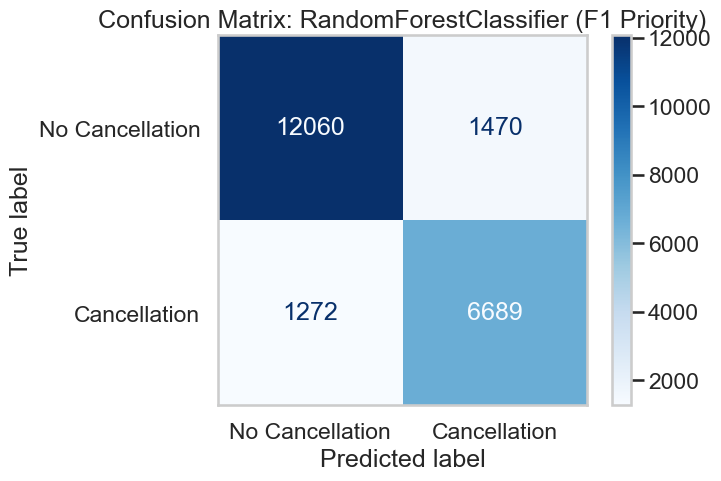

In [ ]:
y_pred_best = f1_rs_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancellation', 'Cancellation'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix: {f1_rs_rf.best_estimator_.named_steps['model'].__class__.__name__} (F1 Priority)")
plt.grid(False)
plt.show()
None

We can see the RandomForest variant is the definitive best overall balanced model because it achieves the highest overall Accuracy (0.87) and Macro F1-score (0.86) among all tested variants.

### Metrics

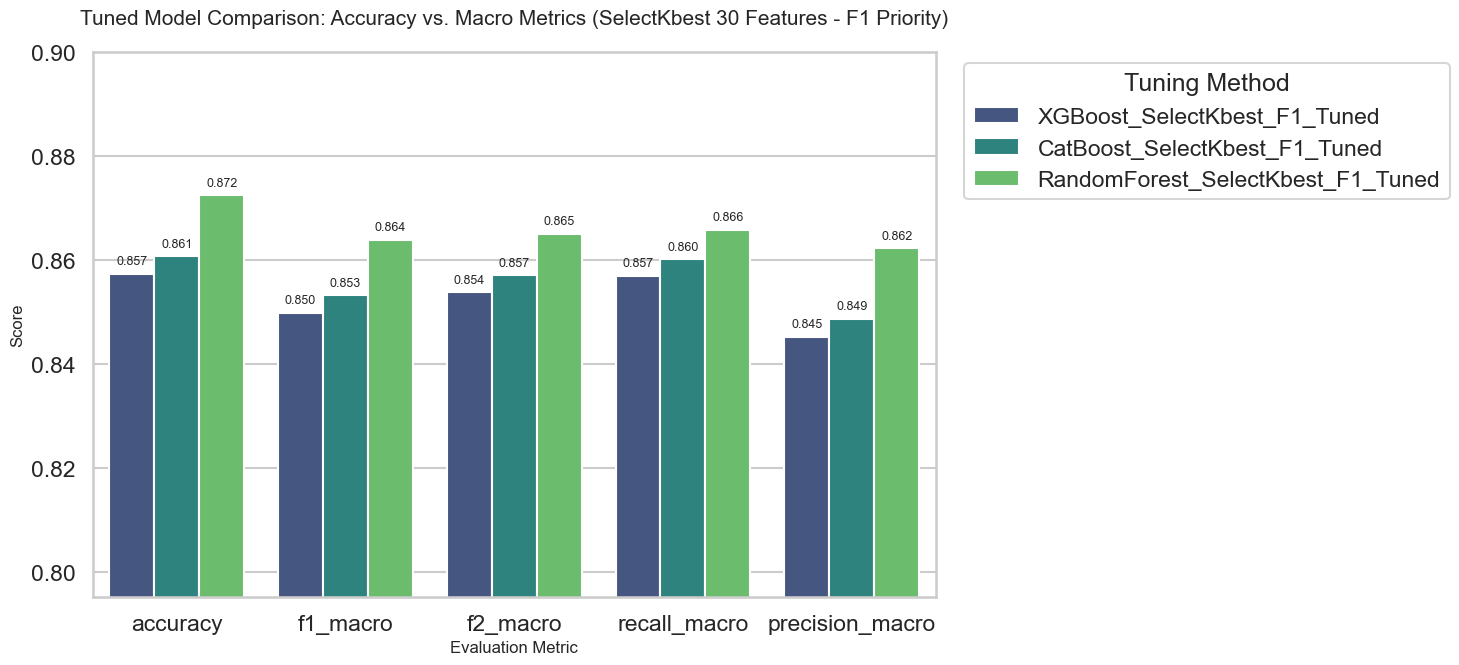

In [46]:
# Convert the list of dicts to a DataFrame
metrics_df = pd.DataFrame(all_metrics)

# Melt the DataFrame: This turns columns (accuracy, f1_macro, etc.) into rows
# so that 'metric' can be used on the X-axis and 'value' on the Y-axis.
plot_df = metrics_df.melt(id_vars="method", var_name="metric", value_name="value")

sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))

ax = sns.barplot(data=plot_df, x="metric", y="value", hue="method", palette="viridis")

# Add data labels
for p in ax.patches:
    if p.get_height() > 0: # Only annotate bars with height
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=9)

plt.ylim(min(plot_df['value']) - 0.05, 0.90) # Dynamic zoom based on the lowest score
plt.title("Tuned Model Comparison: Accuracy vs. Macro Metrics (SelectKbest 30 Features - F1 Priority)", fontsize=15, pad=20)
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Tuning Method")

plt.tight_layout()
plt.show()

## Hypertune the 3 best models on the 30 selectKbest columns (F2 Priority)

In [ ]:
f2_scorer = make_scorer(fbeta_score, beta=2, average='macro') # this will be used now

def get_model_metrics(y_true, y_pred, method_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    f2 = fbeta_score(y_true, y_pred, beta=2, average='macro')
    return {
        "method": method_name,
        "accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"],
        "f2_macro": f2,
        "recall_macro": report["macro avg"]["recall"],
        "precision_macro": report["macro avg"]["precision"],
    }

all_metrics = []

xgb_params = {
    'model__n_estimators': [100, 200, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 6, 9],
    'model__subsample': [0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.7, 0.8, 0.9]
}

cat_params = {
    'model__iterations': [100, 200, 500],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [4, 6, 8],
    'model__l2_leaf_reg': [1, 3, 5, 9]
}

search_results = {}

tuned_models = {
    "XGBoost_SelectKbest_F2_Tuned": (XGBClassifier(random_state=42), xgb_params),
    "CatBoost_SelectKbest_F2_Tuned": (CatBoostClassifier(random_state=42, logging_level='Silent'), cat_params)
}

for name, (model_obj, params) in tuned_models.items():
    pipe = ImbPipeline(steps=[
        ('imputer', SimpleImputer()),
        ('scaler', StandardScaler()),
        ('smote' , SMOTE(random_state=42)),
        ('selector', SelectKBest(score_func=f_classif, k=30)),
        ('model', model_obj)
    ])
    
    # scoring=f2_scorer
    f2_rs = RandomizedSearchCV(pipe, param_distributions=params, n_iter=10, 
                            cv=3, scoring=f2_scorer, n_jobs=-1, random_state=42)
    
    print(f"Tuning {name} for F2 Score...")
    f2_rs.fit(X_train, y_train)
    print(f"Best {name} Params:\n{f2_rs.best_params_}\n")     

    search_results[name] = f2_rs

    y_pred = f2_rs.predict(X_test)
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    all_metrics.append(get_model_metrics(y_test, y_pred, name))

rf_pipe = ImbPipeline(steps=[
    ('imputer', SimpleImputer()), # Placeholder
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_classif, k=30)),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))])

rf_params = {
    # This swaps the entire imputer object during the search
    'imputer': [
        SimpleImputer(strategy='median'), 
        KNNImputer(n_neighbors=5)
    ],
    'model__n_estimators': [100, 300],
    'model__max_depth': [None, 10, 20],   # None allows trees to grow until pure
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2, 4], # Minimum samples required at a leaf node
    'model__max_features': ['sqrt', 'log2'] # How many features to consider at each split
}

f2_rs_rf = RandomizedSearchCV(
    rf_pipe, 
    param_distributions=rf_params, 
    n_iter=20, 
    cv=3, 
    scoring=f2_scorer, # scoring is now F2
    n_jobs=-1, 
    verbose=1, 
    random_state=42
)

print("Tuning RandomForest for F2 Score...")
f2_rs_rf.fit(X_train, y_train)

print(f"Best RandomForest Params:\n{f2_rs_rf.best_params_}\n")
y_pred_rf = f2_rs_rf.predict(X_test)
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
all_metrics.append(get_model_metrics(y_test, y_pred_rf, "RandomForest_SelectKbest_F2_Tuned"))

f2_results_df = pd.DataFrame(all_metrics)

display(f2_results_df.sort_values('f2_macro', ascending=False))

Tuning XGBoost_SelectKbest_F2_Tuned for F2 Score...
Best XGBoost_SelectKbest_F2_Tuned Params:
{'model__subsample': 0.9, 'model__n_estimators': 200, 'model__max_depth': 9, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.9}

[[11624  1906]
 [ 1190  6771]]
              precision    recall  f1-score   support

           0       0.91      0.86      0.88     13530
           1       0.78      0.85      0.81      7961

    accuracy                           0.86     21491
   macro avg       0.84      0.85      0.85     21491
weighted avg       0.86      0.86      0.86     21491

Tuning CatBoost_SelectKbest_F2_Tuned for F2 Score...
Best CatBoost_SelectKbest_F2_Tuned Params:
{'model__learning_rate': 0.1, 'model__l2_leaf_reg': 1, 'model__iterations': 500, 'model__depth': 6}

[[11739  1791]
 [ 1183  6778]]
              precision    recall  f1-score   support

           0       0.91      0.87      0.89     13530
           1       0.79      0.85      0.82      7961

    accuracy    

,method,accuracy,f1_macro,f2_macro,recall_macro,precision_macro
2,RandomForest_SelectKbest_F2_Tuned,0.872412,0.863912,0.865016,0.865787,0.862211
1,CatBoost_SelectKbest_F2_Tuned,0.861616,0.853827,0.857044,0.859514,0.849721
0,XGBoost_SelectKbest_F2_Tuned,0.855940,0.848199,0.851905,0.854825,0.843736


### Confusion Matrix for the best model (F2 Priority)

<Figure size 800x600 with 0 Axes>

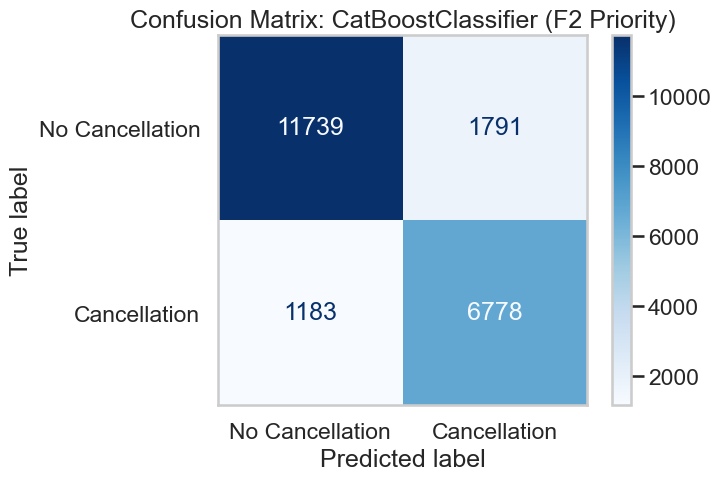

<Figure size 800x600 with 0 Axes>

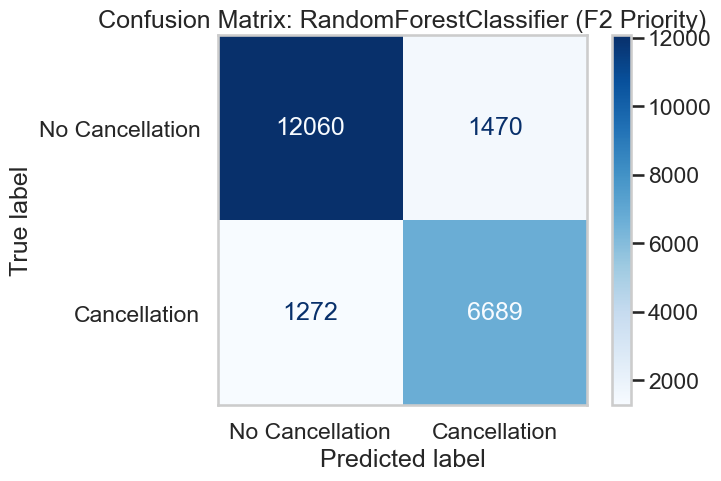

In [56]:
y_pred_best = f2_rs.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancellation', 'Cancellation'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix: {f2_rs.best_estimator_.named_steps['model'].__class__.__name__} (F2 Priority)")
plt.grid(False)
plt.show()
None


y_pred_best = f2_rs_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancellation', 'Cancellation'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix: {f2_rs_rf.best_estimator_.named_steps['model'].__class__.__name__} (F2 Priority)")
plt.grid(False)
plt.show()
None



Here we will choose the CatBoost (F2-Tuned) model as the high-recall specialist because it successfully identifies the highest number of actual cancellations (6,778) compared to the Random Forest variant. While its macro F2​ score is slightly lower, its ability to minimize missed cancellations makes it the superior "safety net" for revenue protection strategies where the cost of an empty room outweighs the cost of a false alarm. This model serves as an aggressive alternative to the primary balanced model, providing the business with a dedicated tool for proactive guest outreach.

### Metrics

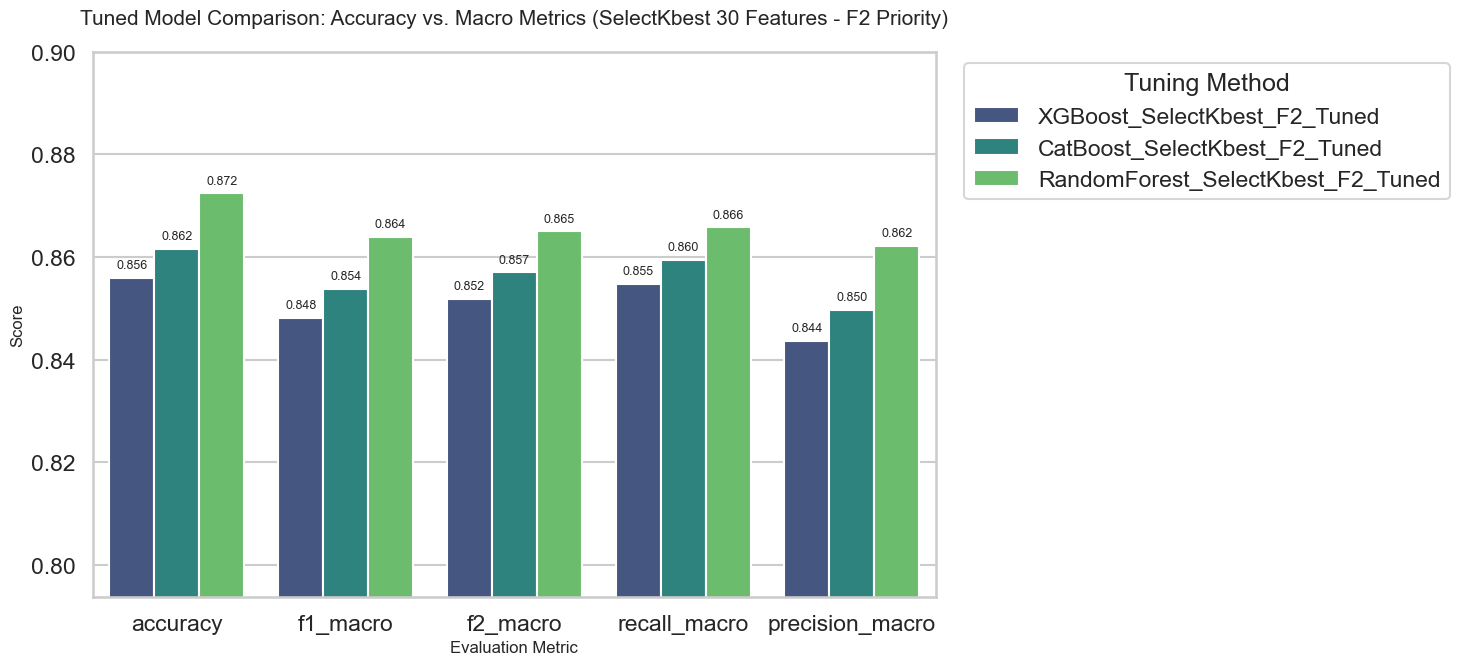

In [49]:
metrics_df = pd.DataFrame(f2_results_df)

plot_df = metrics_df.melt(id_vars="method", var_name="metric", value_name="value")

sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))

ax = sns.barplot(data=plot_df, x="metric", y="value", hue="method", palette="viridis")

# Add data labels
for p in ax.patches:
    if p.get_height() > 0: # Only annotate bars with height
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=9)

# Formatting
plt.ylim(min(plot_df['value']) - 0.05, 0.90) # Dynamic zoom based on the lowest score
plt.title("Tuned Model Comparison: Accuracy vs. Macro Metrics (SelectKbest 30 Features - F2 Priority)", fontsize=15, pad=20)
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Tuning Method")

plt.tight_layout()
plt.show()

## Top 30 Features Retained by MRMR (Plot)

Finding the 30 best features using MRMR...


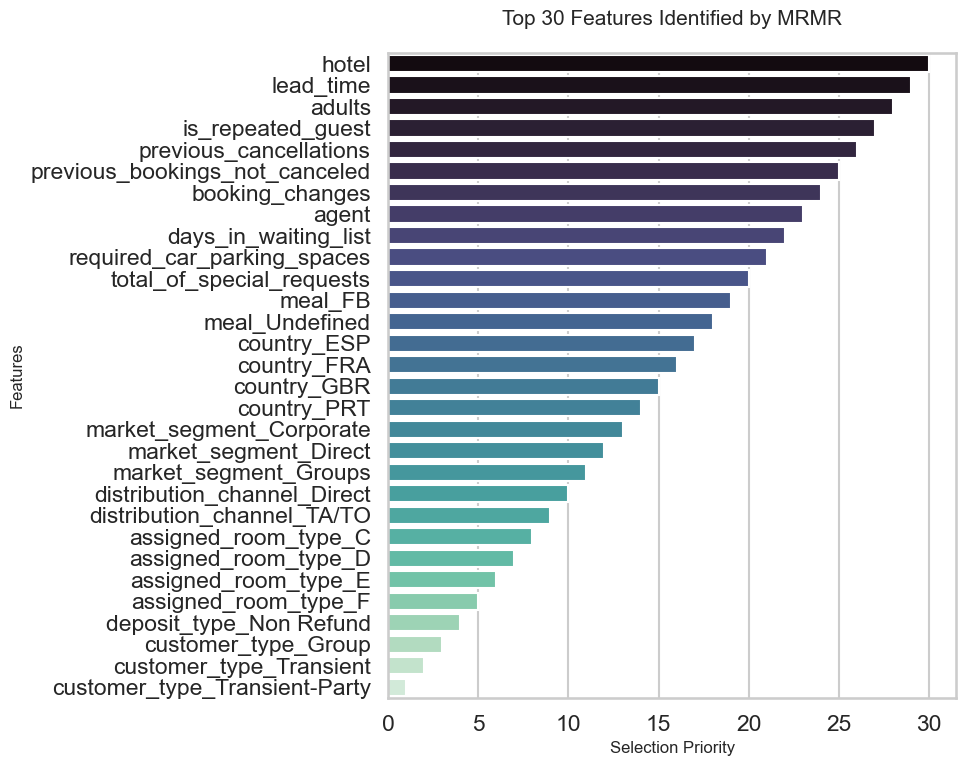

In [ ]:
# Impute and keep the original index
tmp_imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    tmp_imputer.fit_transform(X_train), 
    columns=X_train.columns,
    index=X_train.index
)

# Discovery step
print("Finding the 30 best features using MRMR...")
mrmr_discovery = MRMR(variables=None, method='FCQ', max_features=30)
mrmr_discovery.fit(X_train_imputed, y_train)

# Extract the feature names
if hasattr(mrmr_discovery, 'features_to_select_'):
    selected_features = mrmr_discovery.features_to_select_
elif hasattr(mrmr_discovery, 'features_to_drop_'):
    all_features = X_train_imputed.columns.tolist()
    selected_features = [f for f in all_features if f not in mrmr_discovery.features_to_drop_]
else:
    selected_features = mrmr_discovery.variables_

mrmr_plot_data = pd.Series(
    data=range(len(selected_features), 0, -1), 
    index=selected_features
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
ax = sns.barplot(x=mrmr_plot_data.values, y=mrmr_plot_data.index, palette="mako")

plt.title("Top 30 Features Identified by MRMR", fontsize=15, pad=20)
plt.xlabel("Selection Priority", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

## Hypertune the 3 best models on the best 30 columns from MRMR

In [ ]:
f2_scorer = make_scorer(fbeta_score, beta=2, average='macro') # this will not be used in the current code but will be useful in the final comparison plot

def get_model_metrics(y_true, y_pred, method_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    f2 = fbeta_score(y_true, y_pred, beta=2, average='macro')
    return {
        "method": method_name,
        "accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"],
        "f2_macro": f2,
        "recall_macro": report["macro avg"]["recall"],
        "precision_macro": report["macro avg"]["precision"]
    }

all_metrics = []
search_results = {}

imputer_options = [
    SimpleImputer(strategy='median'), 
    KNNImputer(n_neighbors=3), 
    KNNImputer(n_neighbors=5), 
    KNNImputer(n_neighbors=7)
]

xgb_params = {
    'imputer': imputer_options,
    'model__n_estimators': [100, 200, 500],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 6, 9]
}

cat_params = {
    'imputer': imputer_options,
    'model__iterations': [100, 200, 500],
    'model__depth': [4, 6, 8]
}

tuned_models = {
    "XGBoost_MRMR_Tuned": (XGBClassifier(random_state=42), xgb_params),
    "CatBoost_MRMR_Tuned": (CatBoostClassifier(random_state=42, logging_level='Silent'), cat_params)
}

for name, (model_obj, params) in tuned_models.items():
    pipe = ImbPipeline(steps=[
        ('imputer', SimpleImputer()), 
        ('scaler', StandardScaler()),
        ('smote' , SMOTE(random_state=42)),
        ('selector', MRMR(variables=None, method='FCQ', max_features=30)),
        ('model', model_obj)
    ])
    
    MRMR_rs = RandomizedSearchCV(pipe, param_distributions=params, n_iter=10, 
                            cv=3, scoring='f1_macro', n_jobs=-1, random_state=42)
    
    print(f"Tuning {name}...")
    MRMR_rs.fit(X_train, y_train) 
    print(f"Best {name} Params: {MRMR_rs.best_params_}\n") 
    
    search_results[name] = MRMR_rs
    y_pred = MRMR_rs.predict(X_test)
    print(classification_report(y_test, y_pred))
    print(f' Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}')
    all_metrics.append(get_model_metrics(y_test, y_pred, name))

rf_params = {
    'imputer': imputer_options,
    'model__n_estimators': [100, 300, 800],
    'model__max_depth': [None, 30],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None],
    'model__ccp_alpha': [0.0, 0.0001, 0.001]
}

rf_pipe = ImbPipeline(steps=[
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler()),
    ('smote' , SMOTE(random_state=42)),
    ('selector', MRMR(variables=None, method='FCQ', max_features=30)),
    ('model', RandomForestClassifier(random_state=42))
])

MRMR_rs_rf = RandomizedSearchCV(rf_pipe, param_distributions=rf_params, n_iter=20, 
                           cv=3, scoring='f1_macro', n_jobs=-1, verbose=1, random_state=42)

print("Tuning RandomForest...")
MRMR_rs_rf.fit(X_train, y_train)
print(f"Best RandomForest Params: {MRMR_rs_rf.best_params_}\n")

y_pred_rf = MRMR_rs_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print(f' Confusion Matrix:\n{confusion_matrix(y_test, y_pred_rf)}\n')

all_metrics.append(get_model_metrics(y_test, y_pred_rf, "RandomForest_MRMR_Tuned"))

MRMR_results_df = pd.DataFrame(all_metrics)
display(MRMR_results_df.sort_values('f1_macro', ascending=False))

Tuning XGBoost_MRMR_Tuned...
Best XGBoost_MRMR_Tuned Params: {'model__n_estimators': 500, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'imputer': KNNImputer()}

              precision    recall  f1-score   support

           0       0.90      0.86      0.88     13530
           1       0.78      0.83      0.81      7961

    accuracy                           0.85     21491
   macro avg       0.84      0.85      0.84     21491
weighted avg       0.86      0.85      0.85     21491

 Confusion Matrix:
[[11697  1833]
 [ 1330  6631]]
Tuning CatBoost_MRMR_Tuned...
Best CatBoost_MRMR_Tuned Params: {'model__iterations': 500, 'model__depth': 8, 'imputer': KNNImputer(n_neighbors=3)}

              precision    recall  f1-score   support

           0       0.90      0.87      0.88     13530
           1       0.79      0.84      0.81      7961

    accuracy                           0.86     21491
   macro avg       0.84      0.85      0.85     21491
weighted avg       0.86      0.86  

,method,accuracy,f1_macro,f2_macro,recall_macro,precision_macro
2,RandomForest_MRMR_Tuned,0.856405,0.848247,0.851304,0.853643,0.844309
1,CatBoost_MRMR_Tuned,0.855893,0.847386,0.849977,0.851918,0.843899
0,XGBoost_MRMR_Tuned,0.852822,0.844163,0.846770,0.848729,0.840670


### Confusion Matrix for the MRMR Models (F1 Priority & MRMR)

<Figure size 800x600 with 0 Axes>

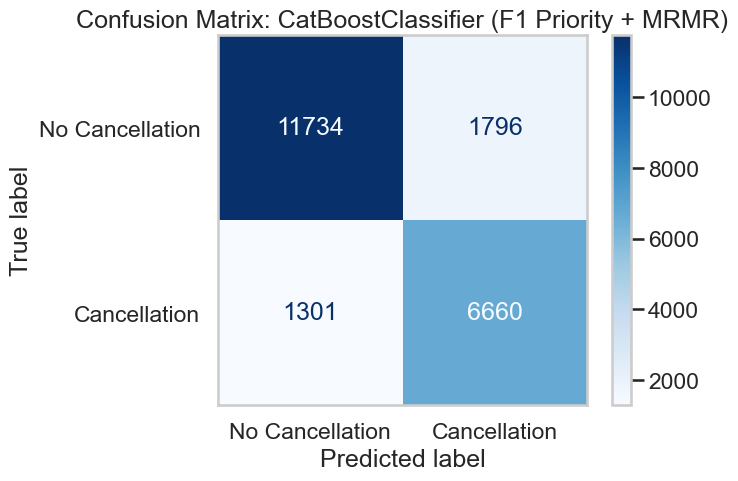

<Figure size 800x600 with 0 Axes>

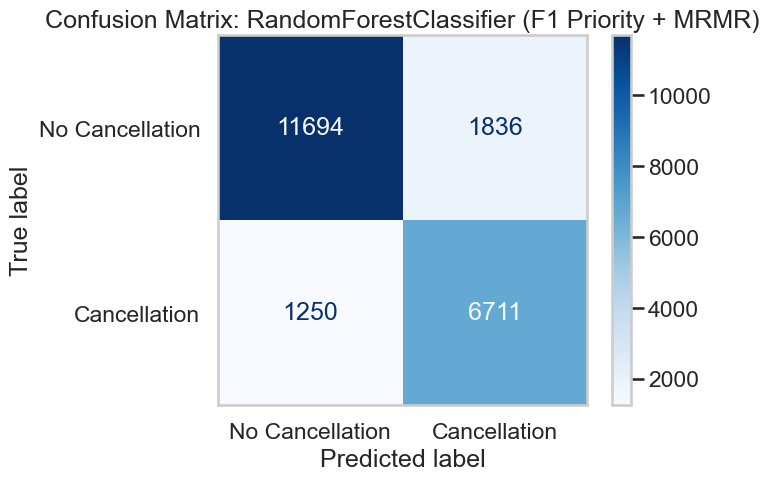

In [57]:
y_pred_best = MRMR_rs.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancellation', 'Cancellation'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix: {MRMR_rs.best_estimator_.named_steps['model'].__class__.__name__} (F1 Priority + MRMR)")
plt.grid(False)
plt.show()
None

y_pred_best = MRMR_rs_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancellation', 'Cancellation'])
disp.plot(cmap='Blues', values_format='d')
plt.title(f"Confusion Matrix: {MRMR_rs_rf.best_estimator_.named_steps['model'].__class__.__name__} (F1 Priority + MRMR)")
plt.grid(False)
plt.show()
None

We are not moving forward with the MRMR variants because they underperform across all key metrics compared to our previous models

### Metrics

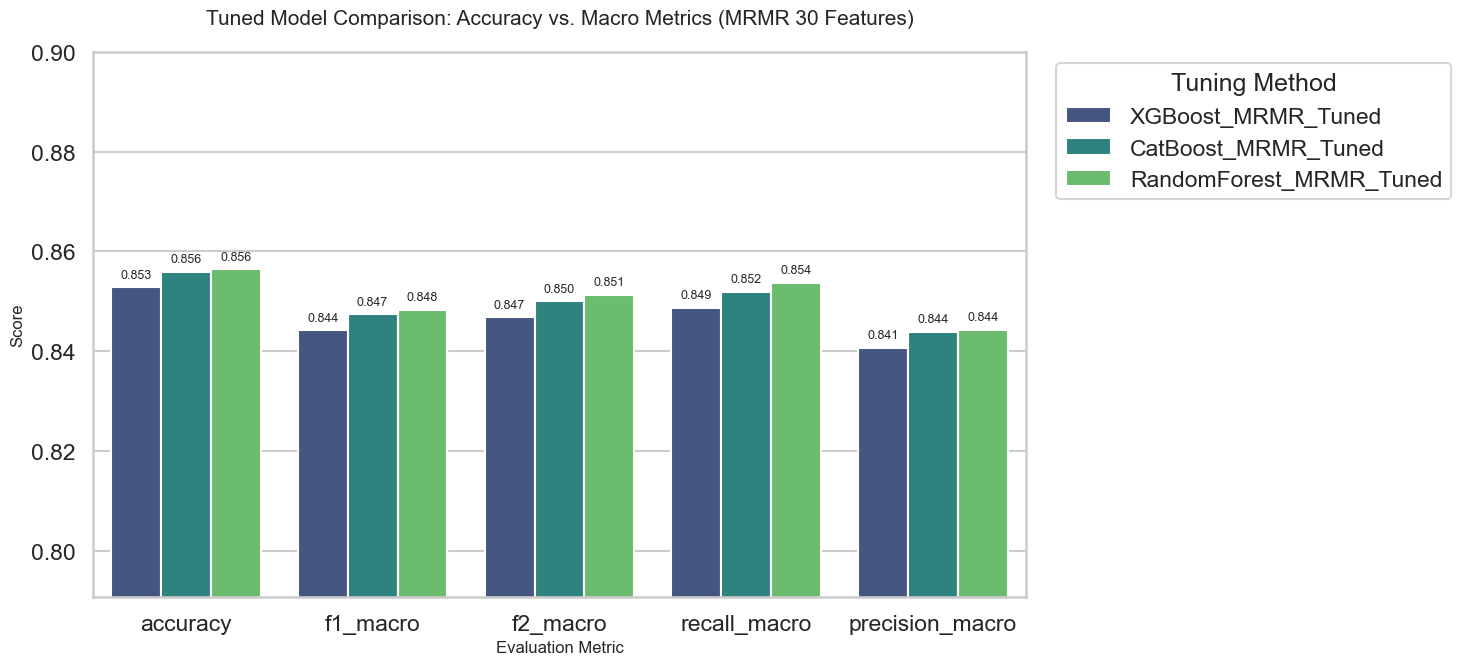

In [53]:
metrics_df = pd.DataFrame(MRMR_results_df)

plot_df = metrics_df.melt(id_vars="method", var_name="metric", value_name="value")

sns.set_style("whitegrid")
plt.figure(figsize=(15, 7))

ax = sns.barplot(data=plot_df, x="metric", y="value", hue="method", palette="viridis")

# Add data labels
for p in ax.patches:
    if p.get_height() > 0: # Only annotate bars with height
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=9)

# Formatting
plt.ylim(min(plot_df['value']) - 0.05, 0.90) # Dynamic zoom based on the lowest score
plt.title("Tuned Model Comparison: Accuracy vs. Macro Metrics (MRMR 30 Features)", fontsize=15, pad=20)
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Tuning Method")

plt.tight_layout()
plt.show()

# Compare all 9 models

,method,accuracy,f1_macro,f2_macro,recall_macro,precision_macro
2,RandomForest_SelectKbest_F1_Tuned,0.872412,0.863912,0.865016,0.865787,0.862211
5,RandomForest_SelectKbest_F2_Tuned,0.872412,0.863912,0.865016,0.865787,0.862211
4,CatBoost_SelectKbest_F2_Tuned,0.861616,0.853827,0.857044,0.859514,0.849721
1,CatBoost_SelectKbest_F1_Tuned,0.860686,0.853246,0.857073,0.860093,0.848659
0,XGBoost_SelectKbest_F1_Tuned,0.857336,0.849829,0.853790,0.856941,0.845177
8,RandomForest_MRMR_Tuned,0.856405,0.848247,0.851304,0.853643,0.844309
3,XGBoost_SelectKbest_F2_Tuned,0.855940,0.848199,0.851905,0.854825,0.843736
7,CatBoost_MRMR_Tuned,0.855893,0.847386,0.849977,0.851918,0.843899
6,XGBoost_MRMR_Tuned,0.852822,0.844163,0.846770,0.848729,0.840670


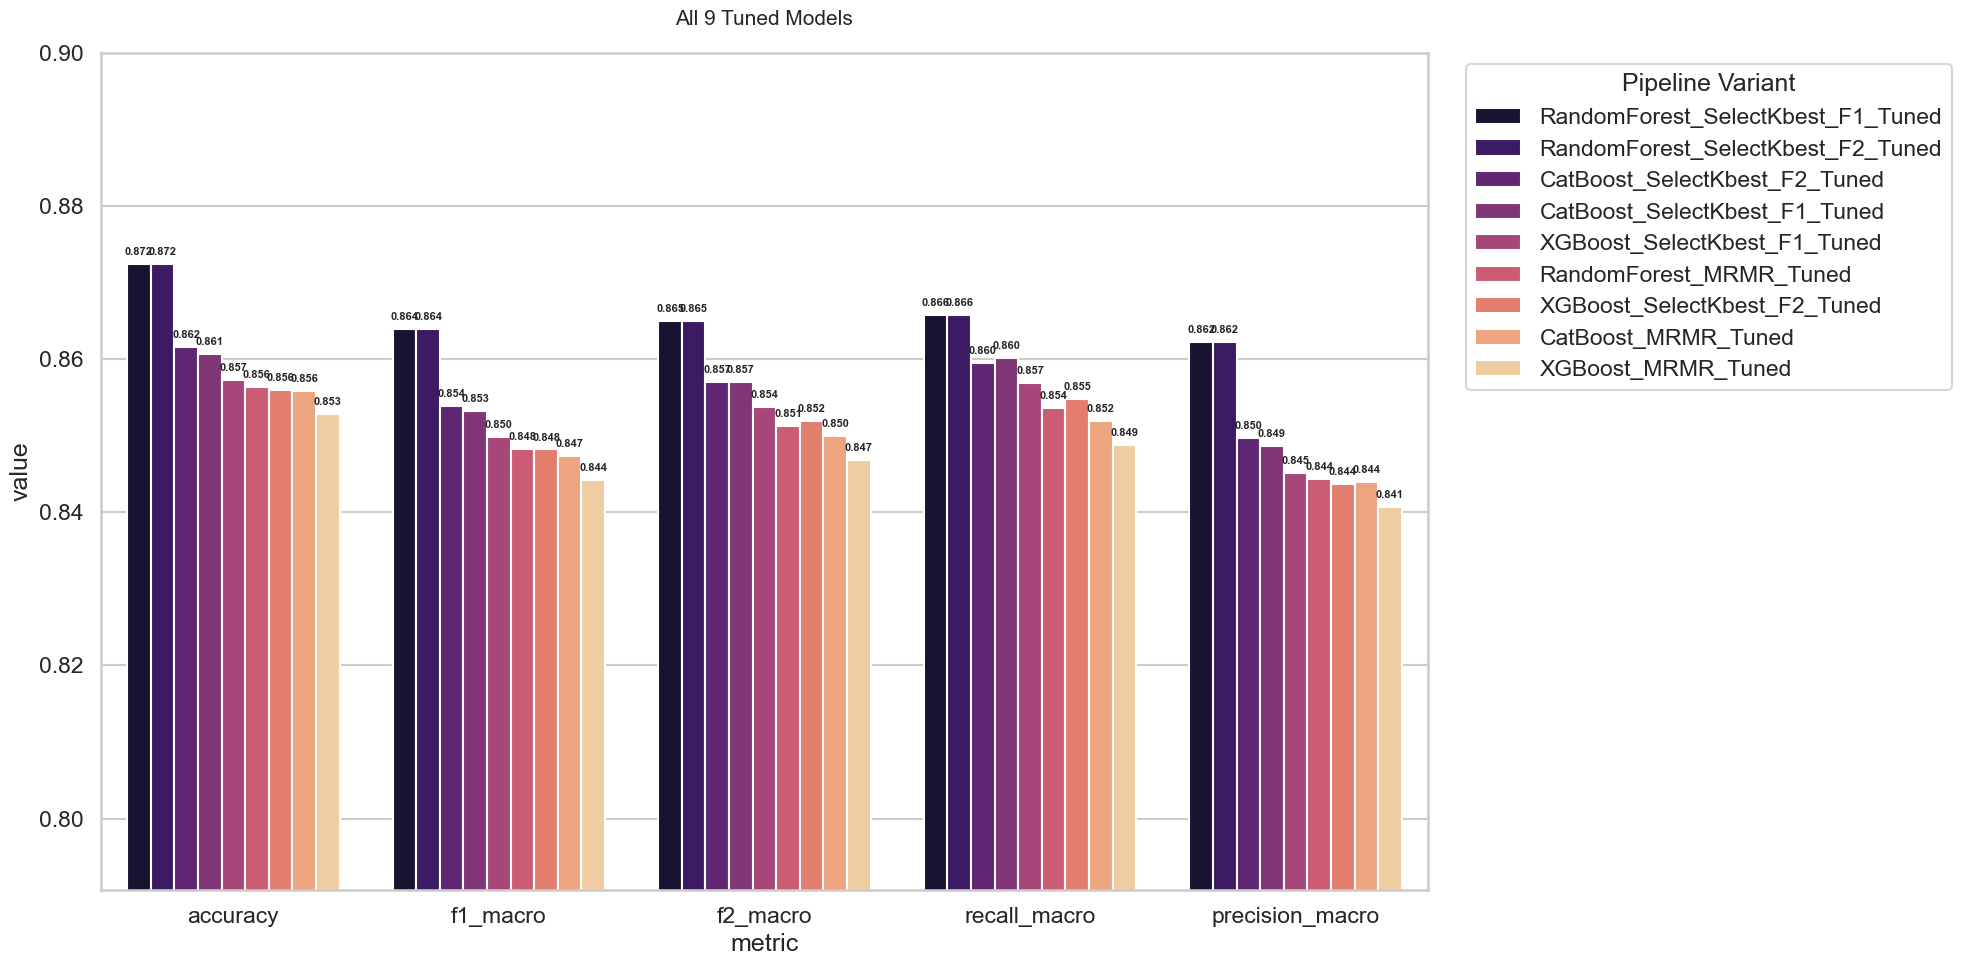

In [58]:
combined_results = pd.concat([f1_results_df, f2_results_df, MRMR_results_df], ignore_index=True)
final_metrics_df = pd.DataFrame(combined_results)

final_metrics_df.sort_values(by='f1_macro', ascending=False, inplace=True)
display(final_metrics_df)

plot_df = final_metrics_df.melt(id_vars="method", var_name="metric", value_name="value")

plt.figure(figsize=(20, 10))
sns.set_style("whitegrid")

ax = sns.barplot(data=plot_df, x="metric", y="value", hue="method", palette="magma")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'bottom', xytext = (0, 5), 
                    textcoords = 'offset points', fontsize=8, fontweight='bold')

plt.ylim(min(plot_df['value']) - 0.05, 0.90) 
plt.title("All 9 Tuned Models", fontsize=15, pad=20)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Pipeline Variant")
plt.tight_layout()
plt.show()

Final Verdict:

We have selected the Random Forest (SelectKbest, F1-Tuned) and the CatBoost (SelectKbest, F2-Tuned) as the two champion models to offer the business distinct operational modes:

The Balanced Model (Random Forest F1) achieved the highest overall Accuracy (0.87) and Macro F1-score (0.86). It is the most robust choice for automated systems because it provides the highest precision for cancellations (0.82), ensuring that guests are not incorrectly flagged and inconvenienced by "False Alarms".

The High-Recall Model (CatBoost F2) serves as an aggressive "Safety Net" for revenue protection. While its macro scores are slightly lower, it successfully identifies the highest number of actual cancellations (6,778). It is optimized to minimize missed cancellations (False Negatives), making it ideal for proactive outreach or inventory overbooking during high-demand periods.

## Proceed with best performing Balanced Model (RandomForest)

### Cross - Validation

Validating Stability for: RandomForestClassifier...

Fold 1 | F1: 0.8632 | Recall: 0.8354 | Precision: 0.8219
Fold 2 | F1: 0.8621 | Recall: 0.8381 | Precision: 0.8174
Fold 3 | F1: 0.8610 | Recall: 0.8280 | Precision: 0.8225
Fold 4 | F1: 0.8634 | Recall: 0.8345 | Precision: 0.8230
Fold 5 | F1: 0.8649 | Recall: 0.8394 | Precision: 0.8227
------------------------------
MEAN PERFORMANCE ACROSS FOLDS
F1 Macro:  0.8629 (±0.0013)
Recall:    0.8351
Precision: 0.8215
------------------------------
F1 Std Dev:0.0013


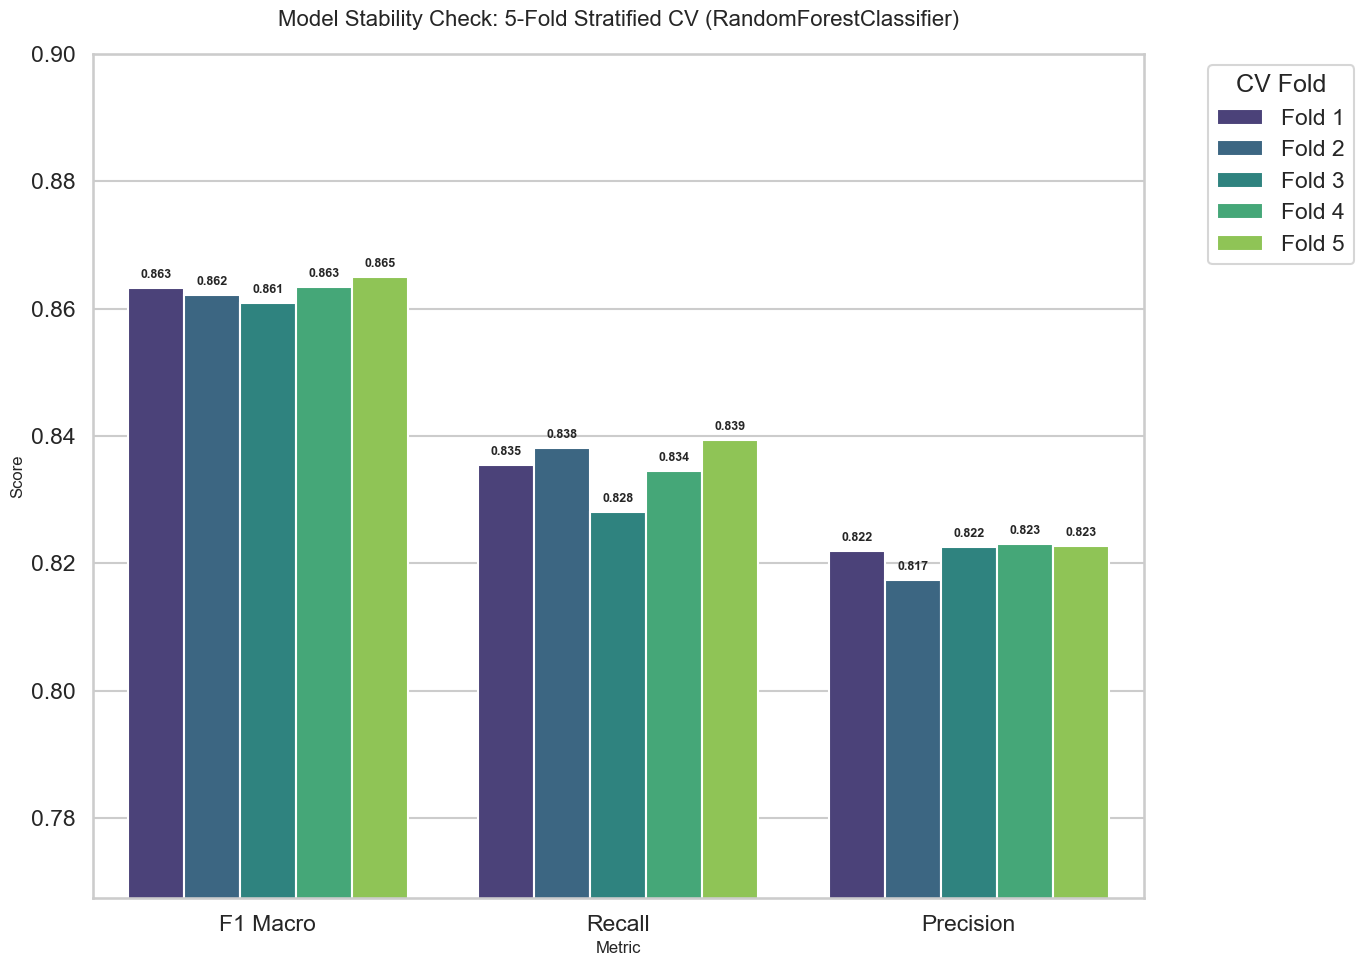

In [59]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics_types = {
    'f1_macro': 'f1_macro', 
    'recall': 'recall', 
    'precision': 'precision'
}

winner_name = f1_rs_rf.best_estimator_.named_steps['model'].__class__.__name__
print(f"Validating Stability for: {winner_name}...\n")

cv_results = cross_validate(
    f1_rs_rf.best_estimator_, 
    X_train, 
    y_train, 
    cv=skf, 
    scoring=cv_metrics_types
)

for i in range(5):
    print(f"Fold {i+1} | F1: {cv_results['test_f1_macro'][i]:.4f} | Recall: {cv_results['test_recall'][i]:.4f} | Precision: {cv_results['test_precision'][i]:.4f}")
    
cv_df = pd.DataFrame({
    'Fold': [f"Fold {i+1}" for i in range(5)],
    'F1 Macro': cv_results['test_f1_macro'],
    'Recall': cv_results['test_recall'],
    'Precision': cv_results['test_precision']
})

cv_melted = cv_df.melt(id_vars='Fold', var_name='Metric', value_name='Score')
print("-" * 30)
print(f"MEAN PERFORMANCE ACROSS FOLDS")
print(f"F1 Macro:  {np.mean(cv_results['test_f1_macro']):.4f} (±{np.std(cv_results['test_f1_macro']):.4f})")

print(f"Recall:    {np.mean(cv_results['test_recall']):.4f}")
print(f"Precision: {np.mean(cv_results['test_precision']):.4f}")
print("-" * 30)
print(f"F1 Std Dev:{np.std(cv_results['test_f1_macro']):.4f}")

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

ax = sns.barplot(data=cv_melted, x='Metric', y='Score', hue='Fold', palette='viridis')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.3f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold')

current_min = cv_melted['Score'].min()
plt.ylim(max(0, current_min - 0.05), 0.90) # Zoomed to show variance, capped at 0.90

plt.title(f"Model Stability Check: 5-Fold Stratified CV ({winner_name})", fontsize=16, pad=20)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.legend(title="CV Fold", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [60]:
cv_df

,Fold,F1 Macro,Recall,Precision
0,Fold 1,0.863214,0.835427,0.821875
1,Fold 2,0.862088,0.838097,0.817430
2,Fold 3,0.860952,0.828046,0.822493
3,Fold 4,0.863394,0.834485,0.822983
4,Fold 5,0.864940,0.839378,0.822715


### Save the Balanced Pipeline & the Parts

In [ ]:
# Ensure the directory exists
pickle_folder = os.path.join("..", "pickle files")
if not os.path.exists(pickle_folder):
    os.makedirs(pickle_folder)

# Define the best pipeline from your search results
best_pipe = f1_rs_rf.best_estimator_ # here we set the best balanced model (F1 Random Forest) from the previous 9 we hypertuned, so we extract its steps

joblib.dump(best_pipe, os.path.join(pickle_folder, "balanced_randomforest_pipeline.pickle")) # full pipe pickle

# Imputer
joblib.dump(best_pipe.named_steps['imputer'], 
            os.path.join(pickle_folder, "balanced_randomforest_imputer.pickle"))
# Scaler
joblib.dump(best_pipe.named_steps['scaler'], 
            os.path.join(pickle_folder, "balanced_randomforest_scaler.pickle"))
# Selector (SelectKBest)
selector_name = 'selector' if 'selector' in best_pipe.named_steps else 'selectk'
joblib.dump(best_pipe.named_steps[selector_name], 
            os.path.join(pickle_folder, "balanced_randomforest_feature_selector.pickle"))
# Model Only
joblib.dump(best_pipe.named_steps['model'], 
            os.path.join(pickle_folder, "balanced_randomforest_final_model.pickle"))

print(f"All components successfully saved to the '{pickle_folder}' directory.")

All components successfully saved to the '..\pickle files' directory.


## Proceed with best performing High_Recall Model (Catboost)

### Cross - Validation

Validating Stability for: CatBoostClassifier...

Fold 1 | F1: 0.8581 | Recall: 0.8524 | Precision: 0.7989
Fold 2 | F1: 0.8502 | Recall: 0.8475 | Precision: 0.7863
Fold 3 | F1: 0.8519 | Recall: 0.8332 | Precision: 0.7992
Fold 4 | F1: 0.8530 | Recall: 0.8456 | Precision: 0.7931
Fold 5 | F1: 0.8555 | Recall: 0.8501 | Precision: 0.7954
------------------------------
MEAN PERFORMANCE ACROSS FOLDS
F1 Macro:  0.8538 (±0.0028)
Recall:    0.8458
Precision: 0.7946
------------------------------
F1 Std Dev:0.0028


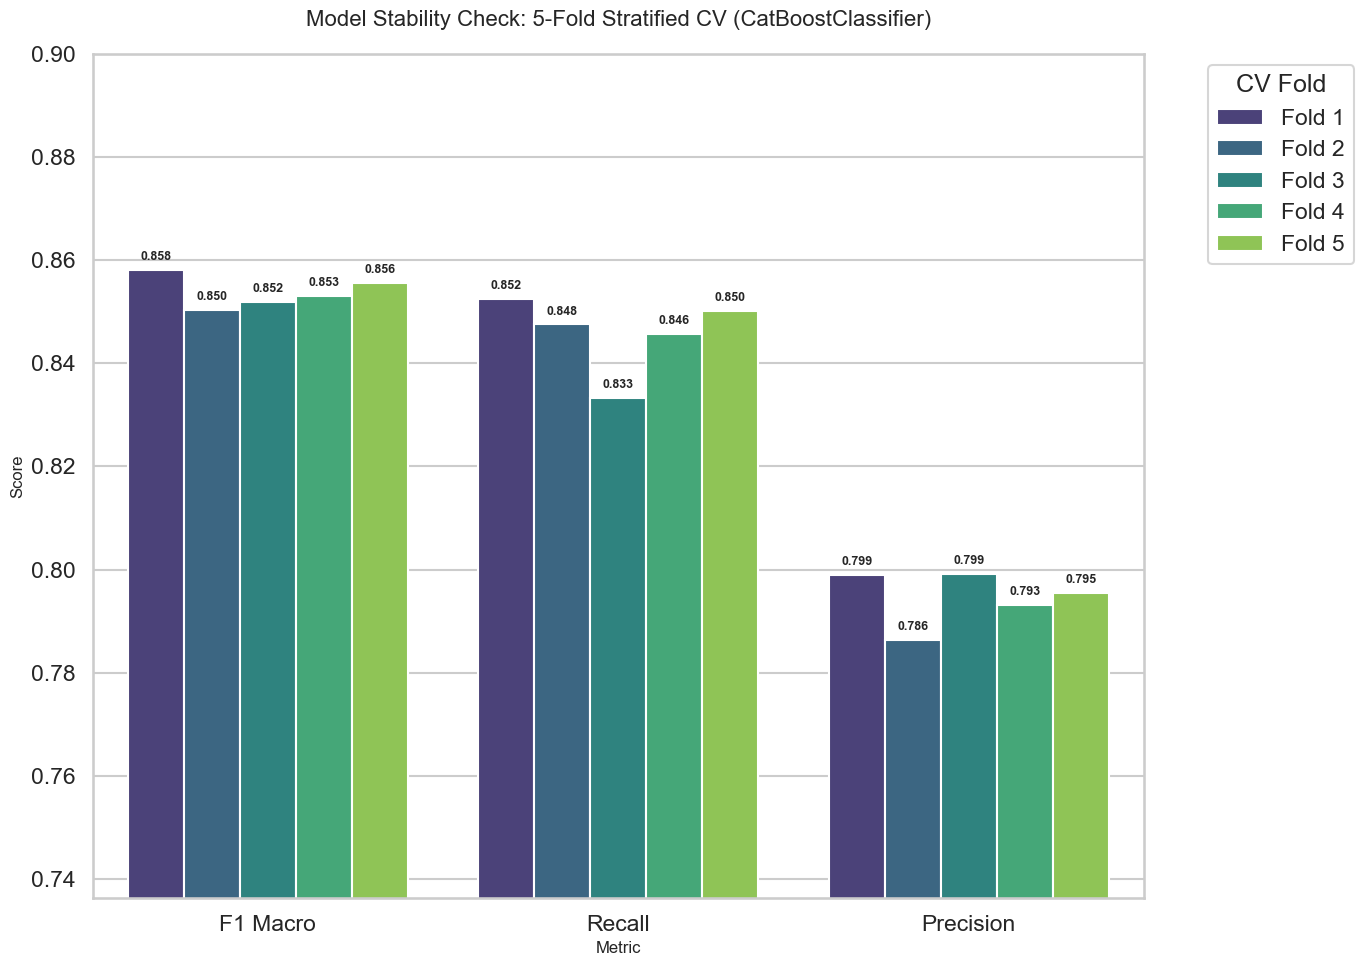

In [63]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_metrics_types = {
    'f1_macro': 'f1_macro', 
    'recall': 'recall', 
    'precision': 'precision'
}

winner_name = f2_rs.best_estimator_.named_steps['model'].__class__.__name__
print(f"Validating Stability for: {winner_name}...\n")

cv_results = cross_validate(
    f2_rs.best_estimator_, 
    X_train, 
    y_train, 
    cv=skf, 
    scoring=cv_metrics_types
)

for i in range(5):
    print(f"Fold {i+1} | F1: {cv_results['test_f1_macro'][i]:.4f} | Recall: {cv_results['test_recall'][i]:.4f} | Precision: {cv_results['test_precision'][i]:.4f}")
    
cv_df = pd.DataFrame({
    'Fold': [f"Fold {i+1}" for i in range(5)],
    'F1 Macro': cv_results['test_f1_macro'],
    'Recall': cv_results['test_recall'],
    'Precision': cv_results['test_precision']
})

cv_melted = cv_df.melt(id_vars='Fold', var_name='Metric', value_name='Score')
print("-" * 30)
print(f"MEAN PERFORMANCE ACROSS FOLDS")
print(f"F1 Macro:  {np.mean(cv_results['test_f1_macro']):.4f} (±{np.std(cv_results['test_f1_macro']):.4f})")

print(f"Recall:    {np.mean(cv_results['test_recall']):.4f}")
print(f"Precision: {np.mean(cv_results['test_precision']):.4f}")
print("-" * 30)
print(f"F1 Std Dev:{np.std(cv_results['test_f1_macro']):.4f}")

plt.figure(figsize=(14, 10))
sns.set_style("whitegrid")

ax = sns.barplot(data=cv_melted, x='Metric', y='Score', hue='Fold', palette='viridis')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.3f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), textcoords='offset points',
                    fontsize=9, fontweight='bold')

current_min = cv_melted['Score'].min()
plt.ylim(max(0, current_min - 0.05), 0.90) # Zoomed to show variance, capped at 0.90

plt.title(f"Model Stability Check: 5-Fold Stratified CV ({winner_name})", fontsize=16, pad=20)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Metric", fontsize=12)
plt.legend(title="CV Fold", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [64]:
cv_df

,Fold,F1 Macro,Recall,Precision
0,Fold 1,0.858069,0.852387,0.798940
1,Fold 2,0.850244,0.847519,0.786276
2,Fold 3,0.851916,0.833229,0.799217
3,Fold 4,0.853005,0.845634,0.793078
4,Fold 5,0.855542,0.850055,0.795358


### Save the F2 Random Forest Pipeline & the Parts (for high recall scenarios)

In [65]:
# Ensure the directory exists
pickle_folder = os.path.join("..", "pickle files")
if not os.path.exists(pickle_folder):
    os.makedirs(pickle_folder)

# Define the best pipeline from your search results
best_pipe = f2_rs.best_estimator_ # here we set the best recall model (F2 Catboost) from the previous 9 we hypertuned, so we extract its steps

joblib.dump(best_pipe, os.path.join(pickle_folder, "high_recall_catboost_pipeline.pickle")) # full pipe pickle

# Imputer
joblib.dump(best_pipe.named_steps['imputer'], 
            os.path.join(pickle_folder, "high_recall_catboost_imputer.pickle"))
# Scaler
joblib.dump(best_pipe.named_steps['scaler'], 
            os.path.join(pickle_folder, "high_recall_catboost_scaler.pickle"))
# Selector (SelectKBest)
joblib.dump(best_pipe.named_steps['selector'], 
            os.path.join(pickle_folder, "high_recall_catboost_feature_selector.pickle"))
# Model Only
joblib.dump(best_pipe.named_steps['model'], 
            os.path.join(pickle_folder, "high_recall_catboost_final_model.pickle"))

print(f"All components successfully saved to the '{pickle_folder}' directory.")

All components successfully saved to the '..\pickle files' directory.


# Create full dataset to train both models on

In [66]:
full_dataset = hotels.drop(['company','arrival_date_year','arrival_date_month','arrival_date_week_number','arrival_date_day_of_month', 'reservation_status_date','reservation_status'], axis=1)
full_dataset = smart_encode_hotels(full_dataset)

X_full = full_dataset.drop(columns=['is_canceled'], errors='ignore')
y_full = full_dataset['is_canceled']

## Train the Balanced Model on full dataset and Save it

In [ ]:
# Best params from the F1-tuned Random Forest search
rf_params = {
    'n_estimators': 100,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'max_depth': None,
    'random_state': 42,
    'class_weight': 'balanced' 
}

rf_pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('selectk', SelectKBest(k=30)),
    ('model', RandomForestClassifier(**rf_params))
])

rf_pipe.fit(X_full, y_full)

pickle_folder = os.path.join("..", "pickle files")
if not os.path.exists(pickle_folder):
    os.makedirs(pickle_folder)

# Save the Full Pipeline
joblib.dump(rf_pipe, os.path.join(pickle_folder, "fully_trained_rf_pipeline.pickle"))

# Save Individual Steps
joblib.dump(rf_pipe.named_steps['imputer'], 
            os.path.join(pickle_folder, "fully_trained_rf_imputer.pickle"))

joblib.dump(rf_pipe.named_steps['scaler'], 
            os.path.join(pickle_folder, "fully_trained_rf_scaler.pickle"))

joblib.dump(rf_pipe.named_steps['selectk'], 
            os.path.join(pickle_folder, "fully_trained_rf_feature_selector.pickle"))

joblib.dump(rf_pipe.named_steps['model'], 
            os.path.join(pickle_folder, "fully_trained_rf_final_model.pickle"))

print(f"Random Forest components successfully saved to '{pickle_folder}'.")

Random Forest components successfully saved to '..\pickle files'.


## Train the HighRecall Model on full dataset and Save it

In [68]:
# best params from the previous search for the F2 tuned CatBoost model
catboost_params = {
    'learning_rate': 0.1, 
    'l2_leaf_reg': 1, 
    'iterations': 500, 
    'depth': 6
}

cat_pipe = Pipeline([
    ('imputer', KNNImputer()),
    ('scaler', StandardScaler()),
    ('selectk', SelectKBest(k=30)),
    ('model', CatBoostClassifier(**catboost_params, verbose=0))
])

cat_pipe.fit(X_full, y_full)

pickle_folder = os.path.join("..", "pickle files")
if not os.path.exists(pickle_folder):
    os.makedirs(pickle_folder)

# Full Pipeline
joblib.dump(cat_pipe, os.path.join(pickle_folder, "fully_trained_catboost_f2_pipeline.pickle"))

# Individual Steps
joblib.dump(cat_pipe.named_steps['imputer'], 
            os.path.join(pickle_folder, "fully_trained_catboost_imputer.pickle"))

joblib.dump(cat_pipe.named_steps['scaler'], 
            os.path.join(pickle_folder, "fully_trained_catboost_scaler.pickle"))

joblib.dump(cat_pipe.named_steps['selectk'], 
            os.path.join(pickle_folder, "fully_trained_catboost_feature_selector.pickle"))

joblib.dump(cat_pipe.named_steps['model'], 
            os.path.join(pickle_folder, "fully_trained_catboost_final_model.pickle"))

print(f"CatBoost components successfully saved to '{pickle_folder}'.")

CatBoost components successfully saved to '..\pickle files'.
